# Classification de commentaires citoyens sur les services publics
**Test technique NLP — TAISS 2026 × Afriklang**

**Contexte.** 150 commentaires citoyens (français, avec quelques insertions éwé/mina),
50 par classe : *Satisfaction*, *Insatisfaction*, *Suggestion*. Le notebook va du nettoyage
du texte à l'interprétation des erreurs.

**Résultats clés** (F1 macro, validation croisée 5 plis × 10 répétitions sur le train de 120 textes) :

- **TF-IDF + régression logistique : 0,717 ± 0,098** ; les réglages lexicaux (stopwords, n-grammes) ne changent rien de démontrable.
- **Encodeur `multilingual-e5-base` figé + régression logistique : 0,981 ± 0,025**, retenu ; 0,967 sur le test (1 erreur sur 30).
- **SetFit** (encodeur affiné) : 0,970, soit pas mieux que l'encodeur figé pour 37 s de GPU en plus.
- Écart creux/dense confirmé par un test de McNemar sur 150 prédictions hors-pli (p ≈ 7·10⁻¹²) ; le test de 30 textes, lui, ne départage rien.

**Plan.** 1. Exploration et prétraitement (1.1 chargement, 1.2 nettoyage, 1.3 visualisations) ·
2. Modélisation (2.1 vectorisation et découpage, 2.2 entraînement, 2.3 évaluation, 2.4 erreurs) ·
3. Conclusion, limites et pistes · 4. Bonus.

**Reproduire.** Python 3.12 ; depuis la racine du dépôt :

```bash
uv venv --python 3.12 && source .venv/bin/activate
uv pip install -r requirements.txt        # variante torch CPU : voir l'en-tête de requirements.txt
jupytext --to ipynb --execute notebook.py  # ou ouvrir analyse_commentaires_citoyens.ipynb
```

La première exécution télécharge les stopwords NLTK et les encodeurs Hugging Face (~1,5 Go),
d'où un accès réseau. L'entraînement SetFit (GPU, ~8 min) est désactivé par défaut :
ses résultats sont relus dans `models/setfit_cv_scores.json` (`RUN_SETFIT_CV = True` pour le refaire).
Toutes les graines sont fixées à 42.

## 0. Configuration et reproductibilité

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Une couleur fixe par classe dans TOUS les graphes (palette validée daltonisme :
# ΔE CVD ≥ 9 sur toutes les paires). Le contraste du vert étant < 3:1 sur fond clair,
# chaque graphe porte des étiquettes visibles : la couleur n'est jamais le seul code.
CLASS_ORDER = ["Satisfaction", "Insatisfaction", "Suggestion"]
CLASS_COLORS = {"Satisfaction": "#1baf7a", "Insatisfaction": "#eb6834", "Suggestion": "#2a78d6"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "grid.color": "#e6e6e3", "grid.linewidth": 0.8,
})

## 1. Exploration et prétraitement
### 1.1 Chargement et exploration

Une seule lecture du CSV ; les modules utiles à toute la partie 1 sont importés ici.

In [2]:
import re
from collections import Counter
from pathlib import Path

from preprocessing import (EWE_LOOKUP, KEPT_FROM_NLTK, NLTK_STOPWORDS_FR, STOPWORDS_FR,
                           clean_text, glossary_key, tokenize)

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv("dataset_nlp_test_tal.csv")
print("shape :", df.shape)
print(df.dtypes.to_string())
print("valeurs manquantes :", int(df.isna().sum().sum()))
print("textes dupliqués   :", int(df["texte"].duplicated().sum()))

shape : (150, 3)
id           int64
texte          str
categorie      str
valeurs manquantes : 0
textes dupliqués   : 0


Deux exemples par classe, texte complet :

In [3]:
with pd.option_context("display.max_colwidth", None):
    display(df.groupby("categorie").head(2).sort_values("categorie", key=lambda labels: labels.map(CLASS_ORDER.index)))

,id,texte,categorie
8,9,"Bonne expérience globale, les choses évoluent positivement.",Satisfaction
7,8,J'ai été agréablement surpris par la rapidité du traitement.,Satisfaction
0,1,Manque total de communication entre les services.,Insatisfaction
4,5,Le formulaire en ligne plante au moment de la soumission.,Insatisfaction
2,3,Envoyer des SMS de confirmation lors de chaque étape du traitement.,Suggestion
1,2,Il serait bien de proposer des tutoriels vidéo pour les démarches en ligne.,Suggestion


150 lignes, 3 colonnes (`id` entier, `texte` et `categorie` chaînes), aucune valeur manquante,
aucun texte dupliqué : pas de nettoyage structurel à faire. Les exemples montrent déjà les
deux formes typiques de la Suggestion : infinitif en tête (« Envoyer des SMS… ») et
tournure impersonnelle au conditionnel (« Il serait bien de… »).

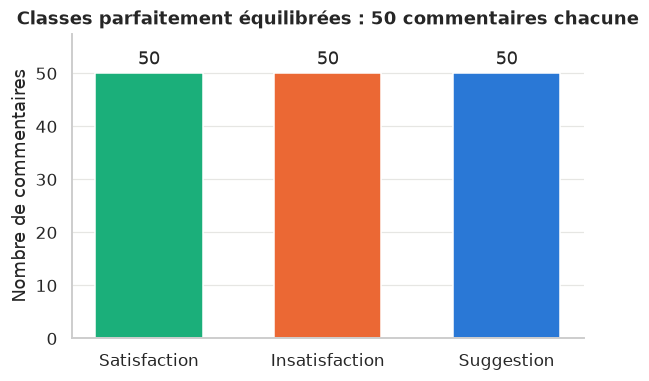

In [4]:
class_counts = df["categorie"].value_counts().reindex(CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar(CLASS_ORDER, class_counts, color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.6)
ax.bar_label(bars, padding=3)
ax.set_ylabel("Nombre de commentaires")
ax.set_ylim(0, class_counts.max() * 1.15)
ax.grid(axis="x", visible=False)
ax.set_title(f"Classes parfaitement équilibrées : {class_counts.iloc[0]} commentaires chacune")
fig.savefig(FIGURES_DIR / "distribution_classes.png")
plt.show()

50 / 50 / 50 : pas de rééquilibrage nécessaire ; l'accuracy et le F1 macro seront proches et
le hasard est à 33 %. Avec seulement 10 commentaires par classe dans un test à 20 %, chaque
erreur pèsera 3,3 points d'accuracy : d'où la validation croisée répétée utilisée plus bas.

**Longueur des textes par classe.**

In [5]:
df["n_mots"] = df["texte"].str.split().str.len()
df["n_caracteres"] = df["texte"].str.len()
length_stats = df.groupby("categorie")[["n_mots", "n_caracteres"]].agg(["mean", "median", "min", "max"]).reindex(CLASS_ORDER)
length_stats.round(1)

n_mots                n_caracteres               
                 mean median min max         mean median min max
categorie                                                       
Satisfaction      8.7    8.0   5  13         57.4   59.0  27  76
Insatisfaction    9.3    9.0   6  13         57.8   57.0  34  78
Suggestion       10.5   10.0   8  15         69.8   70.0  58  84

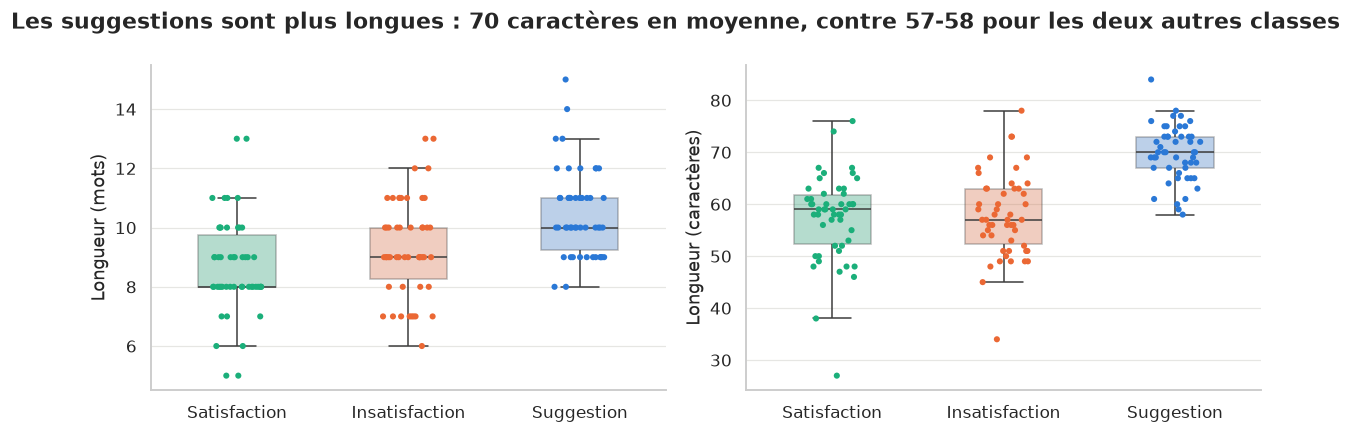

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column, label in zip(axes, ["n_mots", "n_caracteres"], ["mots", "caractères"]):
    sns.boxplot(data=df, x="categorie", y=column, order=CLASS_ORDER, palette=CLASS_COLORS, hue="categorie",
                width=0.45, fliersize=0, boxprops={"alpha": 0.35}, ax=ax)
    sns.stripplot(data=df, x="categorie", y=column, order=CLASS_ORDER, palette=CLASS_COLORS, hue="categorie",
                  size=4, jitter=0.15, ax=ax)
    ax.set(xlabel="", ylabel=f"Longueur ({label})")
    ax.grid(axis="x", visible=False)
mean_chars = length_stats[("n_caracteres", "mean")]
fig.suptitle(f"Les suggestions sont plus longues : {mean_chars['Suggestion']:.0f} caractères en moyenne, "
             f"contre {mean_chars['Satisfaction']:.0f}-{mean_chars['Insatisfaction']:.0f} pour les deux autres classes",
             fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "longueurs.png")
plt.show()

Satisfaction (8,7 mots, 57 caractères) et Insatisfaction (9,3 mots, 58 caractères) ont la même
longueur ; les Suggestions sont plus longues (10,5 mots, 70 caractères) et plus homogènes
(jamais moins de 58 caractères) : une proposition doit nommer à la fois l'action et son objet.
Le minimum absolu (27 caractères) est le commentaire éwé id 73. La longueur seule ne
départage donc que Suggestion du reste.

**Marqueurs linguistiques par classe.** Hypothèse issue de la lecture du corpus : les
classes se distinguent autant par la *forme* de la phrase que par son vocabulaire.
On mesure la part des commentaires de chaque classe qui contient chaque marqueur.

In [7]:
# Noms et possessifs finissant en -er/-re trouvés en tête de phrase à la relecture
# (« Dossier traité rapidement… », « Formulaire papier illisible… ») : ce ne sont pas des infinitifs.
NOT_INFINITIVES = {"dossier", "formulaire", "notre", "votre"}
MARKERS = {
    "infinitif en tête": r"^\w+(?:er|ir|re)\b",
    "conditionnel (-rait/-raient)": r"\w(?:rait|raient)\b",
    "négation / manque": r"\b(?:ne|n['’]|pas|aucune?|manque|sans|jamais|impossible|ni|rien|personne)\b",
    "intensif « très / bien »": r"\b(?:très|bien)\b",
    "point d'exclamation": r"!",
    "chiffre": r"\d",
}


def has_marker(text, name):
    # re Python plutôt que Series.str.contains : le moteur pyarrow de pandas 3 traite « é »
    # comme une frontière de mot, si bien que « traité » y passait pour un conditionnel.
    text = text.lower()
    if name == "infinitif en tête" and text.split()[0] in NOT_INFINITIVES:
        return False
    return re.search(MARKERS[name], text) is not None


def has_ewe_term(text):
    return any(glossary_key(word) in EWE_LOOKUP for word in clean_text(text).split())


marker_flags = pd.DataFrame({name: df["texte"].map(lambda text: has_marker(text, name)) for name in MARKERS})
marker_flags.insert(2, "infinitif OU conditionnel",
                    marker_flags["infinitif en tête"] | marker_flags["conditionnel (-rait/-raient)"])
marker_flags["terme éwé (glossaire)"] = df["texte"].map(has_ewe_term)

# Vérification à l'œil de l'heuristique d'infinitif : premiers mots retenus, par classe.
first_words = df["texte"].str.lower().str.split().str[0]
for label, words in first_words[marker_flags["infinitif en tête"]].groupby(df["categorie"]):
    print(f"{label} : {', '.join(sorted(set(words)))}")

Suggestion : afficher, allonger, augmenter, collaborer, créer, envoyer, former, instaurer, mettre, numériser, ouvrir, proposer, prévoir, publier


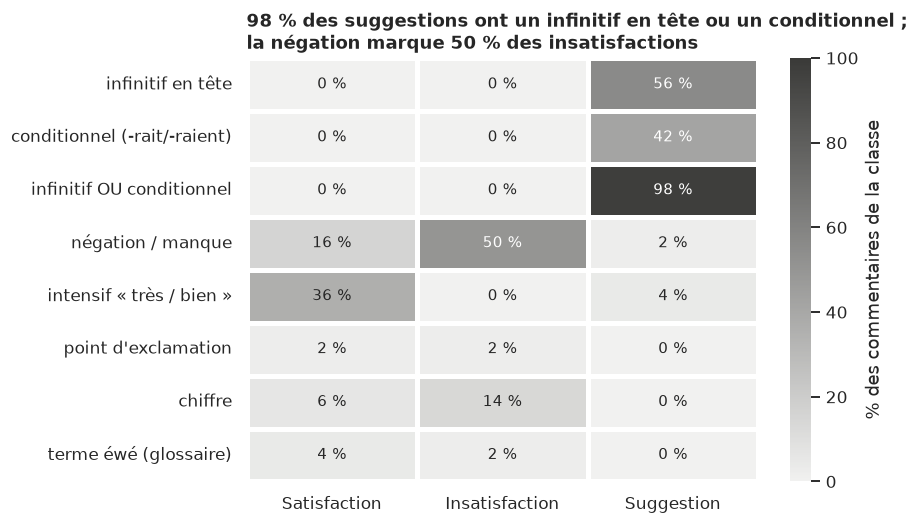

In [8]:
marker_pct = (marker_flags.groupby(df["categorie"]).mean() * 100).reindex(CLASS_ORDER).T
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.heatmap(marker_pct, annot=marker_pct.round().astype(int).astype(str) + " %", fmt="", vmin=0, vmax=100,
            cmap=sns.light_palette("#3a3a38", as_cmap=True), linewidths=2, linecolor="white",
            cbar_kws={"label": "% des commentaires de la classe"}, annot_kws={"fontsize": 10}, ax=ax)
ax.set(xlabel="", ylabel="")
ax.tick_params(left=False, bottom=False)
ax.set_title(f"{marker_pct.loc['infinitif OU conditionnel', 'Suggestion']:.0f} % des suggestions ont un infinitif en tête "
             f"ou un conditionnel ;\nla négation marque {marker_pct.loc['négation / manque', 'Insatisfaction']:.0f} % "
             "des insatisfactions", loc="left")
fig.savefig(FIGURES_DIR / "marqueurs_heatmap.png")
plt.show()

L'hypothèse tient, et elle est nette :

- **Suggestion** : 56 % commencent par un infinitif, 42 % contiennent un conditionnel, et
  **98 % (49/50) ont l'un ou l'autre** ; la seule exception (id 134 « Un espace dédié aux
  jeunes… ») n'a pas de verbe. Ces deux marqueurs sont absents (0 %) des deux autres classes.
- **Insatisfaction** : 50 % contiennent une négation ou un manque (« aucune », « ne…pas »,
  « sans », « manque »), contre 2 % des suggestions. 14 % citent un chiffre (durées : « 3 semaines », « 2 mois »).
- **Satisfaction** : 36 % contiennent « très » ou « bien », 0 % des insatisfactions.
- Piège : 16 % des satisfactions contiennent aussi une négation (« aucun problème »,
  « sans hésitation », « rien à signaler », « je n'ai attendu que 10 minutes ») : la négation d'un
  mot négatif est positive, ce qu'un sac de mots ne voit pas.
- L'éwé ne concerne que 3 commentaires (2 Satisfaction, 1 Insatisfaction) ; « ! » n'apparaît que
  dans 2 d'entre eux.

Conséquence pour le nettoyage : **négations et conditionnels doivent survivre** au filtre de stopwords.

### 1.2 Nettoyage du texte

Le nettoyage est dans `preprocessing.py` pour que le notebook et l'application
Streamlit appliquent exactement la même chaîne. `clean_text` enchaîne :

1. normalisation Unicode **NFC** (un « é » saisi en deux points de code devient un seul caractère) ;
2. minuscules ;
3. **élisions restituées** en forme pleine (`n'ai` → `ne ai`) : la négation élidée et la négation pleine deviennent le même mot `ne` ;
4. suppression des chiffres, de la ponctuation et des caractères spéciaux avec `\w` Unicode, qui **garde les accents français et les lettres éwé** (ɔ, ɛ, ɖ, ƒ, ŋ, ʋ et les tons) — un `[a-z]` les aurait détruits ;
5. **glossaire éwé additif** (détaillé plus bas) ;
6. espaces normalisés.

**Garder ou retirer les accents ?** On mesure combien de mots distincts fusionneraient
si on les retirait.

In [9]:
vocabulary = Counter(word for text in df["texte"] for word in clean_text(text).split())
vocabulary_words = pd.Series(sorted(vocabulary))
merged_without_accents = vocabulary_words.groupby(vocabulary_words.map(glossary_key)).agg(list)
merged_without_accents = merged_without_accents[merged_without_accents.str.len() > 1]
print(f"{len(vocabulary)} mots distincts, dont {sum(not w.isascii() for w in vocabulary)} accentués")
print(f"Paires qui fusionneraient sans accents : {merged_without_accents.tolist()}")

567 mots distincts, dont 149 accentués
Paires qui fusionneraient sans accents : [['a', 'à'], ['demande', 'demandé'], ['des', 'dès'], ['du', 'dû'], ['ou', 'où']]


Sur 567 mots distincts (149 accentués), retirer les accents ne fusionnerait que 5 paires, dont
4 de mots-outils (a/à, des/dès, du/dû, ou/où) et une seule paire de contenu (demande/demandé).
Le gain en vocabulaire est négligeable (567 → 562) ; on **garde les accents** : c'est gratuit,
plus lisible dans les graphiques, et cela évite de traiter les lettres éwé différemment des lettres françaises.

**Stratégie éwé/mina : glossaire additif.** Trois commentaires sont (en partie) en éwé/mina
(ids 73, 131, 139). Les supprimer ferait perdre 2 % du corpus ; les traduire ferait perdre le
signal d'origine. On **garde le token éwé et on ajoute sa glose française** juste après
(`akpe` → `akpe merci`) : un modèle entraîné sur du français profite de « merci », sans que
le mot éwé disparaisse. La recherche dans `EWE_GLOSSARY` se fait sur une clé sans tons ni
accents (`mègbe`, `megbe`, `vɔ̃`, `vo` se retrouvent), mais le texte garde sa graphie.
Les gloses des trois commentaires du corpus ont été validées par un locuteur éwé.

In [10]:
ewe_rows = df[marker_flags["terme éwé (glossaire)"]]
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({"id": ewe_rows["id"], "texte": ewe_rows["texte"],
                          "après clean_text": ewe_rows["texte"].map(clean_text)}))

,id,texte,après clean_text
72,73,Yèvu service la nyuie hafi!,yèvu européen étranger service la nyuie bien hafi vraiment
130,131,"Mele via o, service la mègbe trop!",mele ne pas via demander o service la mègbe retard lent trop
138,139,"Akpe na wò, service très professionnel et efficace.",akpe merci na wò service très professionnel et efficace


Le glossaire ne se déclenche que sur les 3 commentaires attendus (aucun faux positif sur un mot
français du corpus). Après nettoyage, l'id 139 contient « merci » et l'id 131 contient « pas »
et « retard lent » : des indices que le modèle connaît déjà côté français.

**Stopwords.** La liste NLTK française contient justement les mots qui portent la classe :
la négation (`ne`, `pas`) et le conditionnel de *être*/*avoir* (`serait`, `aurait`…).
On les retire de la liste. Occurrences de ces mots par classe :

In [11]:
kept_word_counts = pd.DataFrame({
    label: Counter(word for text in df.loc[df["categorie"] == label, "texte"] for word in clean_text(text).split())
    for label in CLASS_ORDER
}).reindex(sorted(KEPT_FROM_NLTK)).fillna(0).astype(int)
print("Retirés de NLTK sans occurrence ici :", ", ".join(kept_word_counts.index[kept_word_counts.sum(axis=1) == 0]))
kept_word_counts[kept_word_counts.sum(axis=1) > 0]

Retirés de NLTK sans occurrence ici : auraient, aurais, aurait, auriez, aurions, n, seraient, serais, seriez, serions


,Satisfaction,Insatisfaction,Suggestion
ne,2,10,1
pas,2,5,1
serait,0,0,5


Les trois seuls mots retirés de la liste NLTK qui apparaissent ici sont discriminants :
`ne` (9 occurrences en Insatisfaction contre 2 et 1), `pas` (5 contre 2 et 1) et `serait`
(5 occurrences, toutes en Suggestion). Les autres formes conditionnelles sont gardées pour les
textes futurs de l'application. Les autres marqueurs vus plus haut (« très », « bien », « sans »,
« aucune », « jamais ») ne sont pas dans la liste NLTK : aucun besoin de les protéger.

**Ablation.** Est-ce que ça change quelque chose pour un classifieur ? TF-IDF + régression
logistique, F1 macro en validation croisée stratifiée 5 plis × 5 répétitions (mêmes plis
pour les trois variantes).

In [12]:
from functools import partial

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

stopword_variants = {"aucun stopword": set(), "NLTK brut": NLTK_STOPWORDS_FR, "liste personnalisée": STOPWORDS_FR}
cv_splitter = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
ablation_scores = pd.DataFrame({
    name: cross_val_score(make_pipeline(TfidfVectorizer(analyzer=partial(tokenize, stop_words=stop_words)),
                                        LogisticRegression(max_iter=1000)),
                          df["texte"], df["categorie"], cv=cv_splitter, scoring="f1_macro")
    for name, stop_words in stopword_variants.items()
})
ablation_scores.agg(["mean", "std"]).round(3)

,aucun stopword,NLTK brut,liste personnalisée
mean,0.717,0.671,0.697
std,0.082,0.115,0.097


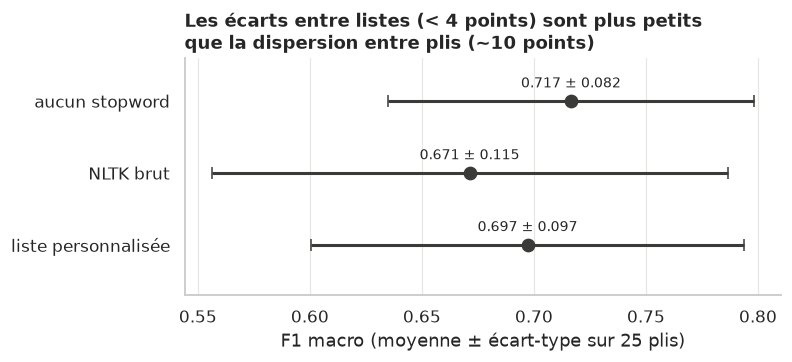

In [13]:
fig, ax = plt.subplots(figsize=(7, 2.8))
summary = ablation_scores.agg(["mean", "std"]).T
ax.errorbar(summary["mean"], summary.index, xerr=summary["std"], fmt="o", color="#3a3a38",
            markersize=8, capsize=4, linewidth=2)
for y, (mean, std) in enumerate(summary.values):
    ax.annotate(f"{mean:.3f} ± {std:.3f}", (mean, y), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=9)
ax.set_xlabel("F1 macro (moyenne ± écart-type sur 25 plis)")
ax.set_ylim(-0.6, len(summary) - 0.3)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_title("Les écarts entre listes (< 4 points) sont plus petits\nque la dispersion entre plis (~10 points)", loc="left")
fig.savefig(FIGURES_DIR / "ablation_stopwords.png")
plt.show()

Résultat honnête : **aucun stopword** obtient le meilleur F1 macro (0,705), devant la liste
personnalisée (0,688) puis NLTK brut (0,673). Mais l'écart-type entre plis (0,085 à 0,117) est
3 à 10 fois plus grand que ces écarts : **aucune différence n'est démontrée** sur 150 textes.
L'avantage du « sans stopword » s'explique : même les mots-outils trahissent la forme de la phrase
(« les » apparaît dans 31 suggestions sur 50 — « Former les agents… » —, « pour » dans 19, « je »
dans 14 satisfactions, « on » dans 7 insatisfactions : « On m'a dit… »).

On garde la **liste personnalisée** pour la suite de l'exploration (nuages et top termes
illisibles sinon, et contrairement à NLTK brut elle conserve `ne`/`pas`/`serait`). Pour la
modélisation, l'option « aucun stopword » reste à comparer : la pondération IDF du TF-IDF
atténue déjà les mots présents partout.

**Tokenisation.** `tokenize` = `clean_text` + découpage sur les espaces + filtre stopwords
et tokens d'une lettre (le « o » éwé de l'id 131, les restes d'élision). Avant / après
(nettoyage, puis tokens sans stopwords) sur six exemples variés :

In [14]:
example_ids = [73, 131, 139, 86, 101, 127]
examples = df.set_index("id").loc[example_ids, ["categorie", "texte"]]
examples.insert(2, "après clean_text", examples["texte"].map(clean_text))  # minuscules, ponctuation et chiffres retirés
examples["tokens"] = examples["texte"].map(lambda text: " · ".join(tokenize(text)))
with pd.option_context("display.max_colwidth", None):
    display(examples)

,categorie,texte,après clean_text,tokens
id,,,,
73,Satisfaction,Yèvu service la nyuie hafi!,yèvu européen étranger service la nyuie bien hafi vraiment,yèvu · européen · étranger · service · nyuie · bien · hafi · vraiment
131,Insatisfaction,"Mele via o, service la mègbe trop!",mele ne pas via demander o service la mègbe retard lent trop,mele · ne · pas · via · demander · service · mègbe · retard · lent · trop
139,Satisfaction,"Akpe na wò, service très professionnel et efficace.",akpe merci na wò service très professionnel et efficace,akpe · merci · na · wò · service · très · professionnel · efficace
86,Insatisfaction,Je regrette de n'avoir aucune autre option que ce service.,je regrette de ne avoir aucune autre option que ce service,regrette · ne · avoir · aucune · autre · option · service
101,Suggestion,Il serait bien d'avoir une version du site en langue locale.,il serait bien de avoir une version du site en langue locale,serait · bien · avoir · version · site · langue · locale
127,Insatisfaction,Aucune version en langue locale disponible pour les non-francophones.,aucune version en langue locale disponible pour les non francophones,aucune · version · langue · locale · disponible · non · francophones


Les tokens éwé restent visibles à côté de leur glose (`akpe · merci`), le « o » éwé d'une lettre
disparaît, la négation élidée de l'id 86 est restituée (`ne`). La paire piège 101 / 127 (même
thème « langue locale ») garde ce qui la sépare : `serait` d'un côté, `aucune` de l'autre — avec
la liste NLTK brute, l'id 101 aurait perdu `serait`.

### 1.3 Visualisations

Toutes les figures par classe partagent la même fonction de tracé (barres horizontales,
valeur en bout de barre, couleur de la classe).

In [15]:
df["tokens"] = df["texte"].map(tokenize)
token_counts = {label: Counter(token for tokens in df.loc[df["categorie"] == label, "tokens"] for token in tokens)
                for label in CLASS_ORDER}


def plot_terms_by_class(values_by_class, xlabel, title, filename, value_format="{:.0f}"):
    fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
    for ax, label in zip(axes, CLASS_ORDER):
        values = values_by_class[label].sort_values()
        ax.barh(values.index, values.values, color=CLASS_COLORS[label], height=0.7)
        for y, value in enumerate(values.values):
            ax.text(value, y, " " + value_format.format(value), va="center", fontsize=9)
        ax.set_title(label)
        ax.set_xlabel(xlabel)
        ax.margins(x=0.18)
        ax.grid(axis="y", visible=False)
    fig.suptitle(title, fontweight="bold", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{filename}.png")
    plt.show()

**Nuages de mots** (calculés sur les tokens, donc sans stopwords et avec les gloses éwé).

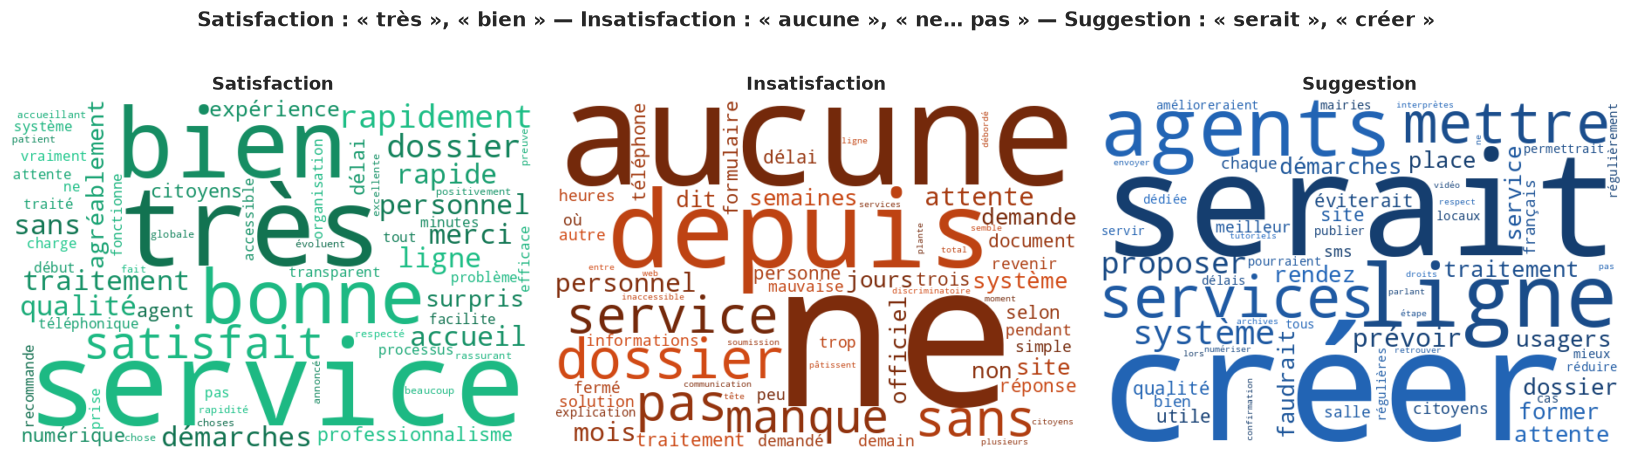

In [16]:
import colorsys

from matplotlib.colors import to_rgb
from wordcloud import WordCloud


def monochrome(hex_color):
    hue, _, saturation = colorsys.rgb_to_hls(*to_rgb(hex_color))
    # Clartés 25-45 % : le vert de Satisfaction est trop clair (< 3:1) pour être lu tel quel sur blanc.
    return lambda *args, random_state, **kwargs: f"hsl({hue * 360:.0f}, {saturation * 100:.0f}%, {random_state.randint(25, 45)}%)"


fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, label in zip(axes, CLASS_ORDER):
    cloud = WordCloud(width=600, height=400, background_color="white", random_state=SEED, max_words=60,
                      color_func=monochrome(CLASS_COLORS[label])).generate_from_frequencies(token_counts[label])
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")
fig.suptitle("Satisfaction : « très », « bien » — Insatisfaction : « aucune », « ne… pas » — Suggestion : « serait », « créer »",
             fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wordclouds.png")
plt.show()

Les plus gros mots sont exactement les marqueurs de la heatmap. « service » domine pourtant le
nuage de Satisfaction (14 occurrences : « service rapide », « excellent service ») : le nuage
reflète la fréquence, pas la spécificité — d'où les deux graphes suivants.

**Top 15 des termes par classe.**

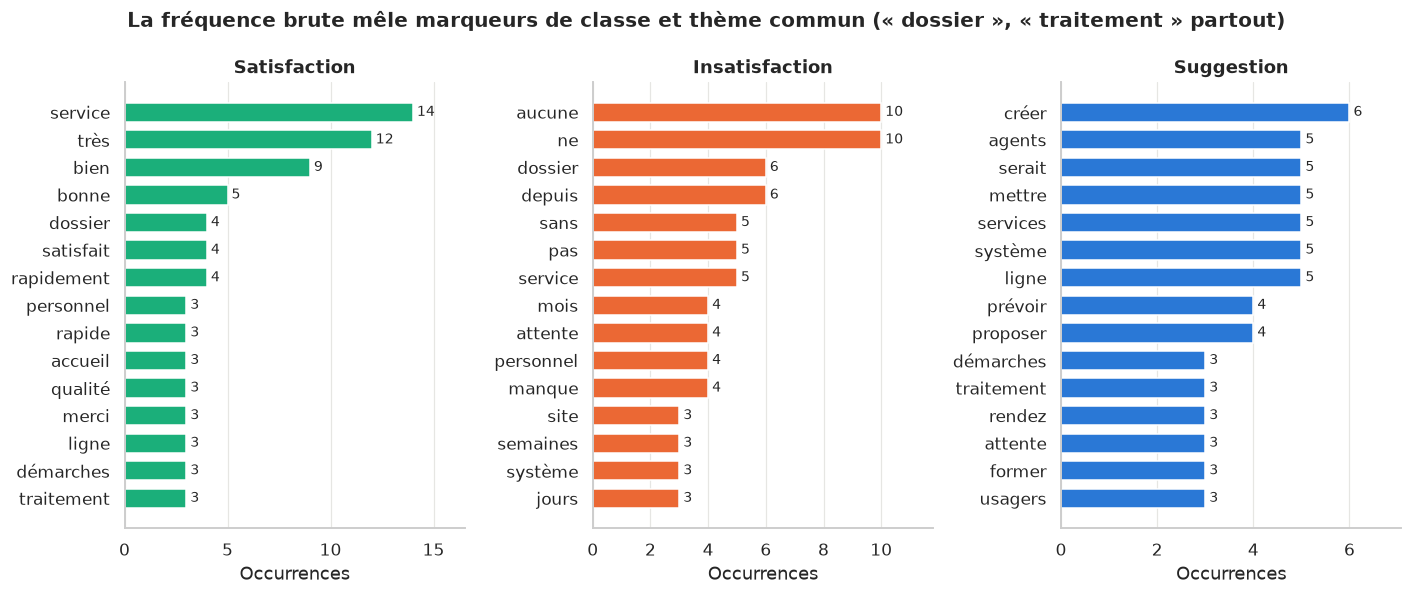

In [17]:
top_terms = {label: pd.Series(dict(token_counts[label].most_common(15))) for label in CLASS_ORDER}
plot_terms_by_class(top_terms, "Occurrences", "La fréquence brute mêle marqueurs de classe et thème commun (« dossier », « traitement » partout)", "top_termes")

Les comptes sont faibles (au plus 14 occurrences) : le corpus est minuscule. « dossier »,
« traitement », « attente » figurent dans les trois classes avec des comptes voisins : ils disent
le thème (l'administration), pas la classe.

**Termes distinctifs : log-odds pondéré avec prior de Dirichlet informatif**
(Monroe, Colaresi & Quinn, 2008). Pour chaque classe contre les deux autres, on compare
les fréquences en lissant par la fréquence du mot dans tout le corpus (le prior), puis on
divise par l'écart-type estimé : le z-score obtenu pénalise les mots rares (trop peu de
preuves) et les mots partout présents (aucune différence). |z| > 1,96 ≈ différence significative à 5 %.

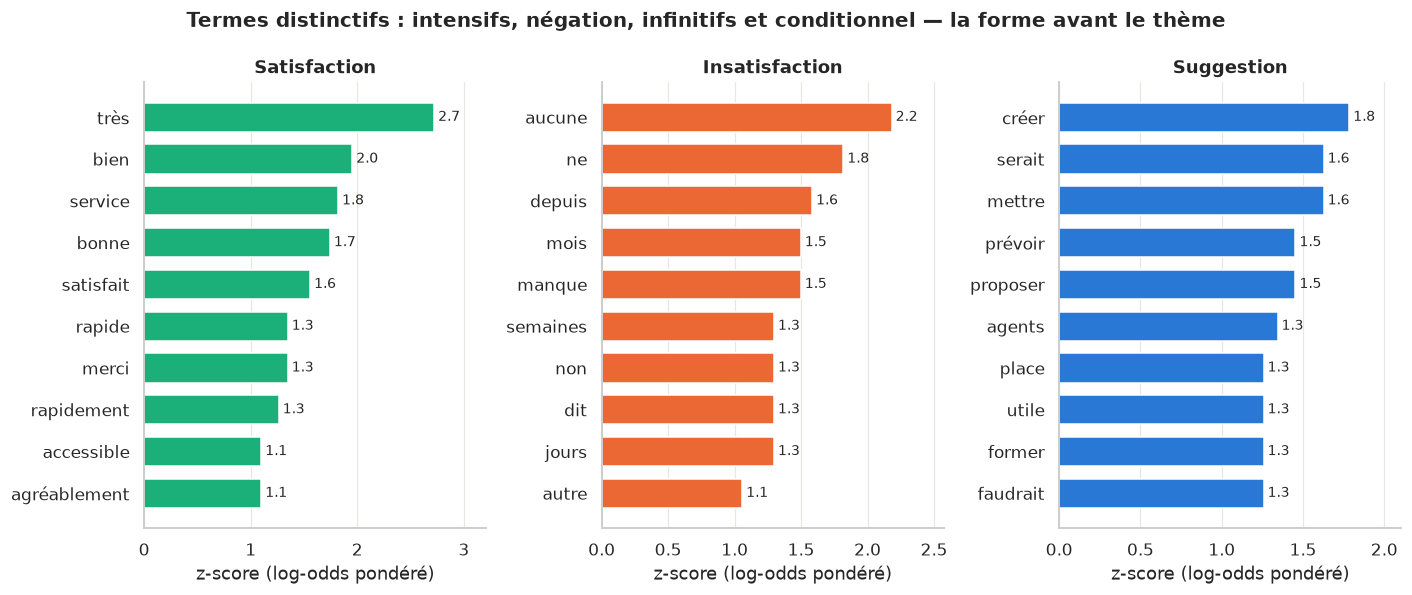

occurrences                                z-score                 \
           Satisfaction Insatisfaction Suggestion Satisfaction Insatisfaction   
dossier               4              6          3          0.0            0.5   
traitement            3              2          3          0.2           -0.3   
attente               2              4          3         -0.3            0.4   
très                 12              0          0          2.7           -1.4   
aucune                1             10          0         -0.8            2.2   
créer                 0              0          6         -0.9           -1.0   

                       
           Suggestion  
dossier          -0.5  
traitement        0.1  
attente          -0.1  
très             -1.4  
aucune           -1.4  
créer             1.8

In [18]:
def log_odds_z_scores(class_counts, rest_counts, prior_counts):
    vocabulary_index = pd.Index(sorted(prior_counts))
    y_class = pd.Series(class_counts).reindex(vocabulary_index, fill_value=0)
    y_rest = pd.Series(rest_counts).reindex(vocabulary_index, fill_value=0)
    alpha = pd.Series(prior_counts).reindex(vocabulary_index)
    n_class, n_rest, alpha_0 = y_class.sum(), y_rest.sum(), alpha.sum()
    delta = (np.log((y_class + alpha) / (n_class + alpha_0 - y_class - alpha))
             - np.log((y_rest + alpha) / (n_rest + alpha_0 - y_rest - alpha)))
    variance = 1 / (y_class + alpha) + 1 / (y_rest + alpha)
    return delta / np.sqrt(variance)


corpus_counts = sum(token_counts.values(), Counter())
z_scores = {label: log_odds_z_scores(token_counts[label], corpus_counts - token_counts[label], corpus_counts)
            for label in CLASS_ORDER}
plot_terms_by_class({label: z.nlargest(10) for label, z in z_scores.items()},
                    "z-score (log-odds pondéré)", "Termes distinctifs : intensifs, négation, infinitifs et conditionnel — la forme avant le thème", "termes_distinctifs", value_format="{:.1f}")
shared_terms = ["dossier", "traitement", "attente", "très", "aucune", "créer"]
pd.concat({"occurrences": pd.DataFrame(token_counts).reindex(shared_terms)[CLASS_ORDER].fillna(0).astype(int),
           "z-score": pd.DataFrame(z_scores).reindex(shared_terms).round(1) + 0.0}, axis=1)

La fréquence brute place « dossier » dans le top 5 de deux classes alors qu'il apparaît 4, 6 et 3
fois selon la classe : son z-score est nul (-0,5 à 0,5). Le log-odds pondéré l'écarte et fait
remonter ce qui est *propre* à une classe : « très » (z = 2,7), « aucune » (2,2), « créer » (1,8),
« serait », « faudrait ». Seuls « très » et « aucune » dépassent 1,96 : avec 150 textes courts,
chaque mot pris isolément reste une preuve faible, ce qui plaide pour des modèles qui combinent
beaucoup d'indices (ou des n-grammes : « il serait », « ne … pas »).

**Projection 2D des embeddings.** Les textes **bruts** sont encodés par
`intfloat/multilingual-e5-base` (multilingue, préfixe `query: ` exigé par e5), puis projetés
par UMAP. Si les classes se mélangent ici, un classifieur sur ces embeddings aura du mal
aux mêmes endroits.

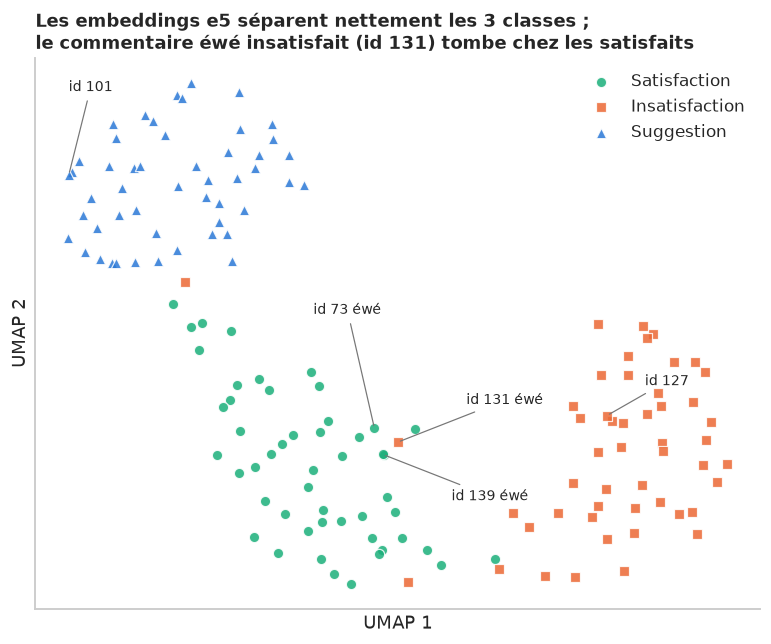

In [19]:
import umap
from huggingface_hub.utils import logging as hub_logging
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors
from transformers.utils import logging as transformers_logging

hub_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

encoder = SentenceTransformer("intfloat/multilingual-e5-base")
embeddings = encoder.encode(("query: " + df["texte"]).tolist(), normalize_embeddings=True, show_progress_bar=False)
projection = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED, n_jobs=1).fit_transform(embeddings)

# Décalages des étiquettes choisis à la main : les trois points éwé sont voisins.
ANNOTATED_IDS = {73: ("73 éwé", (-40, 75)), 131: ("131 éwé", (45, 25)), 139: ("139 éwé", (45, -30)),
                 127: ("127", (25, 20)), 101: ("101", (0, 55))}
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for label, marker in zip(CLASS_ORDER, ["o", "s", "^"]):
    mask = (df["categorie"] == label).to_numpy()
    ax.scatter(*projection[mask].T, color=CLASS_COLORS[label], marker=marker, s=45, alpha=0.85,
               edgecolor="white", linewidth=0.8, label=label)
for comment_id, (text, offset) in ANNOTATED_IDS.items():
    x, y = projection[df.index[df["id"] == comment_id][0]]
    ax.annotate(f"id {text}", (x, y), xytext=offset, textcoords="offset points", fontsize=9,
                arrowprops={"arrowstyle": "-", "color": "#777", "linewidth": 0.8})
ax.legend(frameon=False, loc="best")
ax.set(xticks=[], yticks=[], xlabel="UMAP 1", ylabel="UMAP 2")
ax.set_title("Les embeddings e5 séparent nettement les 3 classes ;\nle commentaire éwé insatisfait (id 131) tombe chez les satisfaits",
             loc="left")
fig.savefig(FIGURES_DIR / "umap.png")
plt.show()

Pour chiffrer le chevauchement : un commentaire est « en zone mixte » si la majorité de ses
5 plus proches voisins (cosinus, espace d'embedding complet, pas la projection) est d'une autre classe.

In [20]:
neighbor_indices = NearestNeighbors(n_neighbors=6, metric="cosine").fit(embeddings).kneighbors(embeddings)[1][:, 1:]
neighbor_majority = [Counter(df["categorie"].iloc[row]).most_common(1)[0][0] for row in neighbor_indices]
mixed_zone = df.assign(classe_voisins=neighbor_majority).query("classe_voisins != categorie")
print(f"{len(mixed_zone)} commentaires en zone mixte sur {len(df)}")
with pd.option_context("display.max_colwidth", None):
    display(mixed_zone[["id", "categorie", "classe_voisins", "texte"]])

7 commentaires en zone mixte sur 150


,id,categorie,classe_voisins,texte
4,5,Insatisfaction,Satisfaction,Le formulaire en ligne plante au moment de la soumission.
41,42,Suggestion,Satisfaction,Une application mobile dédiée faciliterait les démarches pour tous.
46,47,Satisfaction,Insatisfaction,Je n'ai attendu que 10 minutes avant d'être pris en charge.
49,50,Insatisfaction,Satisfaction,Je n'ai reçu aucun accusé de réception de ma demande.
77,78,Satisfaction,Suggestion,La clarté des informations fournies facilite les démarches.
108,109,Insatisfaction,Satisfaction,"Je suis venu à l'ouverture, on m'a dit de revenir à 14h."
130,131,Insatisfaction,Satisfaction,"Mele via o, service la mègbe trop!"


- Les trois classes forment trois groupes distincts, Suggestion étant le plus isolé : les
  embeddings captent l'intention (proposer / se plaindre / féliciter), pas seulement le thème.
  Les ids 101 (Suggestion) et 127 (Insatisfaction), au même thème « langue locale », sont chacun
  dans le groupe de leur classe.
- Les **trois commentaires éwé tombent dans le groupe Satisfaction**, y compris l'id 131 qui est
  une plainte : le modèle ne comprend pas « mele … o » / « mègbe » et ne garde que « service … trop! ».
  C'est l'argument concret pour le glossaire additif.
- 7 commentaires (5 %) ont un voisinage majoritairement d'une autre classe ; ce sont les candidats
  naturels aux erreurs de la partie 2 : négation à sens positif (id 47 « Je n'ai attendu que
  10 minutes »), suggestion sans infinitif proche d'un constat positif (id 42 « …faciliterait les
  démarches » contre id 78 « …facilite les démarches » : seul le temps du verbe diffère), plaintes
  sans mot négatif (id 109 « on m'a dit de revenir à 14h », id 5 « le formulaire en ligne plante »).

## 2. Modélisation
### 2.1 Vectorisation et découpage

Découpage 80/20 stratifié, `random_state` fixé.

In [21]:
import gc
import json
import os
import subprocess
import sys
import textwrap
import time
from collections import defaultdict
from io import BytesIO
from itertools import islice

import joblib
import torch
from datasets import Dataset
from datasets.utils.logging import disable_progress_bar as disable_datasets_progress_bar
from scipy.stats import binomtest
from setfit import SetFitModel, Trainer, TrainingArguments
from setfit import logging as setfit_logging
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict, learning_curve,
                                     train_test_split)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from threadpoolctl import threadpool_limits
from transformers import set_seed

set_seed(SEED)  # random, numpy et torch (CPU + GPU) : l'entraînement SetFit est le seul tirage aléatoire sur GPU
# Matrices minuscules (120 × ~6 000) : la synchronisation de 12 threads OpenBLAS coûte plus que le calcul.
# Mesuré ici : un pli TF-IDF caractères + LogReg passe de 2,1 s à 0,05 s avec un seul thread.
threadpool_limits(limits=1, user_api="blas")
setfit_logging.set_verbosity_error()
disable_datasets_progress_bar()
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

texts, labels = df["texte"], df["categorie"]
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, stratify=labels, random_state=SEED)
pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}).reindex(CLASS_ORDER)

,train,test
categorie,,
Satisfaction,40,10
Insatisfaction,40,10
Suggestion,40,10


**Un test de 30 textes est un instrument grossier.** Chaque erreur y coûte 3,3 points
d'accuracy, et l'intervalle de confiance d'une accuracy de 90 % sur 30 textes s'étend
d'environ 80 % à 100 %. Deux règles en découlent :

- **choisir** (représentation, hyperparamètres, modèle) par validation croisée stratifiée
  **répétée sur le train seul** : 5 plis × 10 répétitions = 50 estimations, mêmes plis pour
  tous les modèles (comparaisons appariées) ;
- **rapporter** le score test une seule fois par modèle, avec un intervalle de confiance
  bootstrap à 95 %.

In [22]:
# Les 10 premiers plis (2 répétitions) servent aussi à SetFit, trop coûteux pour 50 entraînements.
cv_train = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
# Prédictions hors-pli sur les 150 textes, pour l'analyse d'erreurs (le test n'en contiendra que quelques-unes).
oof_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

**Représentation creuse.** Deux vues complémentaires du texte nettoyé :

- **mots et bigrammes** (`tokenize` de la partie 1) : « ne … pas », « il serait », « très bien » ;
- **n-grammes de caractères** 2–5 à l'intérieur des mots (`char_wb`) : ils captent les
  morphèmes repérés en partie 1 sans dictionnaire — la terminaison du conditionnel `rait`
  (« faciliterait », « faudrait »), l'infinitif `er_` (« créer », « former ») — et rapprochent
  les variantes d'un même mot (« aucun / aucune », « mègbe / megbe » en éwé, fautes de frappe).

`sublinear_tf` (1 + log tf) car un mot répété dans un texte court n'est pas deux fois plus
probant. Le tokenizer ne filtre aucun stopword : le filtre devient un hyperparamètre
du vectoriseur, testé en 2.2. On compare d'abord les représentations, régression logistique fixe.

In [23]:
# Le tokenizer de la partie 1 sans filtre : les stopwords passent par le paramètre `stop_words` du vectoriseur.
WORD_OPTIONS = dict(tokenizer=partial(tokenize, stop_words=frozenset()), token_pattern=None, lowercase=False,
                    ngram_range=(1, 2))


def word_tfidf():
    return TfidfVectorizer(**WORD_OPTIONS, sublinear_tf=True)


def char_tfidf():
    return TfidfVectorizer(analyzer="char_wb", preprocessor=clean_text, ngram_range=(2, 5), sublinear_tf=True)


def word_char_union():
    return FeatureUnion([("mots", word_tfidf()), ("caracteres", char_tfidf())])


def text_pipeline(features, classifier):
    # Le vectoriseur est dans le pipeline : il est ré-ajusté sur le seul train de chaque pli.
    return Pipeline([("features", features), ("clf", classifier)])


def plot_score_intervals(cv_scores, title, filename, test_scores=None, colors=None):
    """Point = F1 macro moyen en CV, barre = ± un écart-type entre plis, losange creux = F1 sur le test."""
    summary = cv_scores.agg(["mean", "std", "count"]).T
    fig, ax = plt.subplots(figsize=(8.5, 0.75 * len(summary) + 1.4))
    for y, (name, (mean, std, n_folds)) in enumerate(summary.iterrows()):
        color = (colors or {}).get(name, "#3a3a38")
        ax.errorbar(mean, y, xerr=std, fmt="o", color=color, markersize=8, capsize=4, linewidth=2)
        ax.annotate(f"{mean:.3f} ± {std:.3f}", (mean, y), xytext=(0, 9), textcoords="offset points",
                    ha="center", fontsize=9)
        if test_scores is not None:
            ax.plot(test_scores[name], y, marker="D", markersize=8, markerfacecolor="white",
                    markeredgecolor=color, markeredgewidth=1.5, linestyle="none",
                    label="F1 sur le test (30 textes)" if y == 0 else None)
    ax.set_yticks(range(len(summary)), [f"{name}\n({n_folds:.0f} plis)" for name, n_folds in summary["count"].items()])
    ax.set_ylim(-0.6, len(summary) - 0.3)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("F1 macro (moyenne ± écart-type en CV sur le train)")
    if test_scores is not None:
        ax.legend(frameon=False, loc="lower left", fontsize=9)
    ax.set_title(title, loc="left")
    fig.savefig(FIGURES_DIR / f"{filename}.png")
    plt.show()

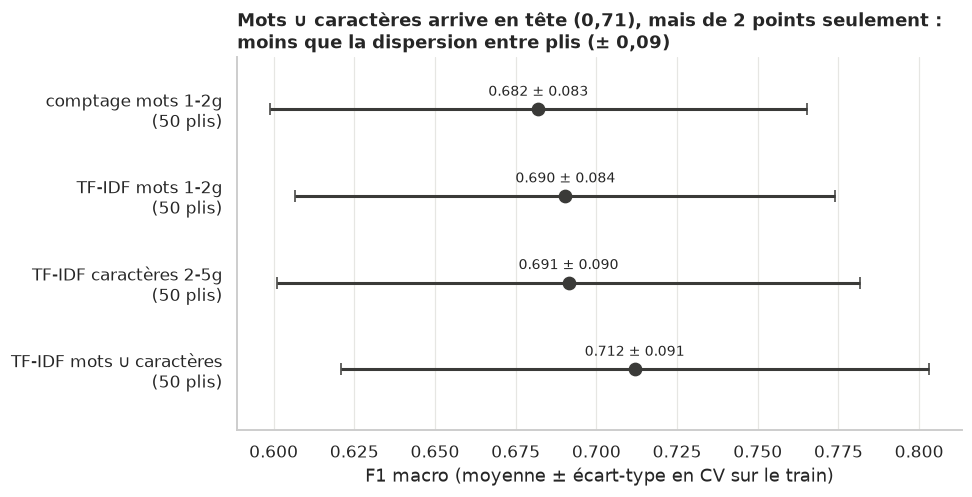

In [24]:
VECTORIZERS = {
    "comptage mots 1-2g": CountVectorizer(**WORD_OPTIONS),
    "TF-IDF mots 1-2g": word_tfidf(),
    "TF-IDF caractères 2-5g": char_tfidf(),
    "TF-IDF mots ∪ caractères": word_char_union(),
}
# C = 10 pour tous : on isole l'effet de la représentation ; C est optimisé ensuite pour celle retenue.
vectorizer_scores = pd.DataFrame({
    name: cross_val_score(text_pipeline(vectorizer, LogisticRegression(C=10, max_iter=2000)),
                          X_train, y_train, cv=cv_train, scoring="f1_macro")
    for name, vectorizer in VECTORIZERS.items()
})
plot_score_intervals(vectorizer_scores, "Mots ∪ caractères arrive en tête (0,71), mais de 2 points seulement :\nmoins que la dispersion entre plis (± 0,09)", "comparaison_vectorisations")

**Lecture.** Les quatre représentations creuses sont dans un mouchoir : 0,682 (comptage),
0,690 (TF-IDF mots), 0,691 (TF-IDF caractères) et **0,712 pour l'union** ; l'écart-type entre
plis (0,08 à 0,09) est quatre fois plus grand que le meilleur écart. On retient l'union mots
∪ caractères : c'est la plus haute, elle gagne 2 points sur chacune de ses deux moitiés (les
deux vues se complètent), et ce choix ne coûte rien (6 000 colonnes, 0,3 Mo). Mais ce
n'est pas une victoire démontrée : la partie 1 laissait déjà prévoir qu'aucun réglage
lexical ne ferait franchir le plafond de ~0,7 sur ces 150 textes.

**Représentation dense : encodeur e5 figé + régression logistique.** Les embeddings
`multilingual-e5-base` de la partie 1 (textes bruts, préfixe `query: `, normalisés) sont
réutilisés tels quels : l'encodeur n'apprend rien, un embedding ne dépend que de son texte et
jamais des étiquettes, les calculer une fois pour les 150 textes ne crée donc aucune fuite. Seule
la régression logistique posée dessus est entraînée, dans chaque pli. On ajoute la variante
`multilingual-e5-small` (118 M paramètres contre 278 M) : l'application doit tenir dans ~1 Go de RAM.
Textes bruts plutôt que nettoyés : essai fait, F1 CV identique à ± 0,001 pour les deux encodeurs
(ponctuation et majuscules ne gênent pas un modèle pré-entraîné sur du texte brut).

In [25]:
E5_CHECKPOINTS = {"e5-base": "intfloat/multilingual-e5-base", "e5-small": "intfloat/multilingual-e5-small"}
dense_encoders = {"e5-base": encoder, "e5-small": SentenceTransformer(E5_CHECKPOINTS["e5-small"])}
embedding_cache = {"e5-base": dict(zip(texts, embeddings)), "e5-small": {}}


def embed(batch, encoder_name):
    # Chaque texte n'est encodé qu'une fois, puis relu dans le cache à chaque pli.
    cache = embedding_cache[encoder_name]
    unseen = [text for text in dict.fromkeys(batch) if text not in cache]
    if unseen:
        cache.update(zip(unseen, dense_encoders[encoder_name].encode(
            ["query: " + text for text in unseen], normalize_embeddings=True, show_progress_bar=False)))
    return np.vstack([cache[text] for text in batch])


def frozen_encoder_pipeline(encoder_name):
    return text_pipeline(FunctionTransformer(embed, kw_args={"encoder_name": encoder_name}),
                         LogisticRegression(max_iter=2000))

**SetFit** (`paraphrase-multilingual-mpnet-base-v2`) va plus loin : il **affine** l'encodeur
par apprentissage contrastif sur des paires de textes (même classe / classes différentes),
puis pose une régression logistique sur les embeddings affinés. C'est la méthode conçue
pour quelques dizaines d'exemples par classe : 120 textes donnent 2 400 paires
(`num_iterations=10`), soit ~25 s d'entraînement sur une RTX 2070.

### 2.2 Entraînement

**Modèles creux : régression logistique et SVM linéaire.** Avec ~7 000 n-grammes pour
120 textes, les classes sont presque linéairement séparables et chaque texte n'active
qu'une poignée de colonnes : c'est le terrain des modèles linéaires régularisés. Random Forest
(arbres profonds sur des colonnes presque toujours nulles) et Naive Bayes (indépendance
des n-grammes, absurde ici puisque chaque mot produit une dizaine de n-grammes de caractères
corrélés) sont écartés par choix, pas par oubli.

Grille : force de régularisation `C` × filtre de stopwords sur les mots (aucun ou
`STOPWORDS_FR` ; les n-grammes de caractères voient toujours tout le texte). Score :
F1 macro, sur les 50 plis du train.

In [26]:
def tuned(pipeline, grid):
    return GridSearchCV(pipeline, grid, cv=cv_train, scoring="f1_macro")


STOPWORD_OPTIONS = [None, sorted(STOPWORDS_FR)]
searches = {
    "TF-IDF + LogReg": tuned(text_pipeline(word_char_union(), LogisticRegression(max_iter=2000)),
                             {"clf__C": [1, 10, 100, 1000], "features__mots__stop_words": STOPWORD_OPTIONS}),
    "TF-IDF + SVM linéaire": tuned(text_pipeline(word_char_union(), LinearSVC(random_state=SEED)),
                                   {"clf__C": [0.1, 1, 10, 100], "features__mots__stop_words": STOPWORD_OPTIONS}),
    **{f"{encoder_name} figé + LogReg": tuned(frozen_encoder_pipeline(encoder_name), {"clf__C": [0.1, 1, 10, 100]})
       for encoder_name in dense_encoders},
}
for search in searches.values():
    search.fit(X_train, y_train)  # refit=True : le meilleur réglage est ré-entraîné sur tout le train


def readable(value):
    if value is None:
        return "aucun"
    return "STOPWORDS_FR" if isinstance(value, list) else value


pd.DataFrame({name: {"F1 CV": round(search.best_score_, 3),
                     **{param.split("__")[-1]: readable(value) for param, value in search.best_params_.items()}}
              for name, search in searches.items()}).T

,F1 CV,C,stop_words
TF-IDF + LogReg,0.717,1000,aucun
TF-IDF + SVM linéaire,0.715,100,aucun
e5-base figé + LogReg,0.981,1.0,NaN
e5-small figé + LogReg,0.935,10.0,NaN


**Lecture.**

- **Stopwords : « aucun » gagne pour les deux modèles creux**, comme dans l'ablation de la
  partie 1 : les mots-outils (« les », « pour », « je ») portent la forme de la phrase.
- **`C` est au bord de la grille** (1 000 pour la régression logistique, 100 pour le SVM) :
  le modèle préfère presque pas de régularisation, ce qui est cohérent avec des classes
  quasi séparables en haute dimension. Le gain sur `C = 10` est minime (0,717 contre 0,712),
  donc élargir la grille ne changerait rien d'utile.
- **Les deux modèles creux sont indiscernables** (0,717 et 0,715) : le choix entre eux est
  une affaire d'usage, la régression logistique donne des probabilités, le SVM non.
- **Les modèles denses sont à un autre niveau** : e5-base 0,981 (`C = 1`), e5-small 0,935
  (`C = 10`), SetFit 0,970 (calculé plus bas).

**SetFit.** 15 entraînements (5 plis × 2 répétitions sur le train, 5 plis hors-pli sur les
150 textes pour l'analyse d'erreurs) + l'entraînement final : ~8 min sur GPU. Les résultats
sont mis en cache dans `models/setfit_cv_scores.json` ; avec `RUN_SETFIT_CV = False` le
notebook relit ce cache et s'exécute en quelques minutes sans GPU.

In [27]:
RUN_SETFIT_CV = False
SETFIT_CHECKPOINT = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
SETFIT_CACHE = MODELS_DIR / "setfit_cv_scores.json"
SETFIT_REPEATS = 2


def train_setfit(train_texts, train_labels):
    set_seed(SEED)
    model = SetFitModel.from_pretrained(SETFIT_CHECKPOINT, labels=CLASS_ORDER)
    args = TrainingArguments(batch_size=16, num_epochs=1, num_iterations=10, seed=SEED, report_to="none",
                             save_strategy="no", logging_strategy="no", show_progress_bar=False,
                             output_dir=str(MODELS_DIR / "setfit" / "checkpoints"))
    dataset = Dataset.from_dict({"text": list(train_texts), "label": list(train_labels)})
    Trainer(model=model, args=args, train_dataset=dataset).train()
    return model


def most_probable(proba):
    return np.array(CLASS_ORDER)[np.asarray(proba).argmax(axis=1)]


def setfit_proba(model, batch):
    proba = model.predict_proba(list(batch), as_numpy=True)
    return pd.DataFrame(proba, columns=model.model_head.classes_)[CLASS_ORDER].to_numpy()


def setfit_fold_proba(train_texts, train_labels, evaluation_texts):
    proba = setfit_proba(train_setfit(train_texts, train_labels), evaluation_texts)
    # Le Trainer garde des références circulaires vers le modèle : sans ramasse-miettes explicite,
    # les modèles des plis précédents s'accumulent et saturent les 8 Go de la carte au 3e pli.
    gc.collect()
    torch.cuda.empty_cache()
    return proba


def module_size_mb(module):
    return sum(parameter.numel() * parameter.element_size() for parameter in module.parameters()) / 1e6


def joblib_size_mb(model):
    buffer = BytesIO()
    joblib.dump(model, buffer)
    return buffer.tell() / 1e6


if RUN_SETFIT_CV:
    cv_f1 = []
    for train_part, validation_part in islice(cv_train.split(X_train, y_train), 5 * SETFIT_REPEATS):
        fold_proba = setfit_fold_proba(X_train.iloc[train_part], y_train.iloc[train_part], X_train.iloc[validation_part])
        cv_f1.append(f1_score(y_train.iloc[validation_part], most_probable(fold_proba), average="macro"))
    oof_proba_setfit = np.zeros((len(texts), len(CLASS_ORDER)))
    for train_part, held_out in oof_splitter.split(texts, labels):
        oof_proba_setfit[held_out] = setfit_fold_proba(texts.iloc[train_part], labels.iloc[train_part],
                                                       texts.iloc[held_out])
    start = time.perf_counter()
    setfit_model = train_setfit(X_train, y_train)
    setfit_seconds = time.perf_counter() - start
    setfit_model.save_pretrained(str(MODELS_DIR / "setfit"))
    SETFIT_CACHE.write_text(json.dumps({
        "cv_f1": cv_f1, "test_proba": setfit_proba(setfit_model, X_test).tolist(),
        "oof_proba": oof_proba_setfit.tolist(), "train_seconds": setfit_seconds,
        "size_mb": module_size_mb(setfit_model.model_body) + joblib_size_mb(setfit_model.model_head),
    }, indent=1))
setfit_results = json.loads(SETFIT_CACHE.read_text())
print(f"SetFit, F1 CV sur {len(setfit_results['cv_f1'])} plis : "
      f"{np.mean(setfit_results['cv_f1']):.3f} ± {np.std(setfit_results['cv_f1'], ddof=1):.3f}")

SetFit, F1 CV sur 10 plis : 0.970 ± 0.029


**Modèles finaux.** Chaque modèle est ré-entraîné sur tout le train avec son meilleur réglage
(déjà fait par `GridSearchCV`), puis évalué **une seule fois** sur le test en 2.3.

In [28]:
MODEL_NAMES = [*searches, "SetFit"]
FAMILY = {"TF-IDF + LogReg": "creuse", "TF-IDF + SVM linéaire": "creuse", "e5-base figé + LogReg": "dense figée",
          "e5-small figé + LogReg": "dense figée", "SetFit": "dense affinée"}
# Gris pour le creux, violet pour le dense : les couleurs de classe restent réservées aux classes.
FAMILY_COLORS = {"creuse": "#3a3a38", "dense figée": "#4a3aa7", "dense affinée": "#9085e9"}
EXPLAINABILITY = {"TF-IDF + LogReg": "forte : coefficient × TF-IDF par mot, probabilités",
                  "TF-IDF + SVM linéaire": "forte : poids par n-gramme, sans probabilités",
                  "e5-base figé + LogReg": "faible : 768 dimensions opaques",
                  "e5-small figé + LogReg": "faible : 384 dimensions opaques",
                  "SetFit": "faible : encodeur affiné opaque"}

final_models = {name: search.best_estimator_ for name, search in searches.items()}
cv_scores = pd.DataFrame({
    name: [search.cv_results_[f"split{fold}_test_score"][search.best_index_] for fold in range(search.n_splits_)]
    for name, search in searches.items()
})
cv_scores["SetFit"] = pd.Series(setfit_results["cv_f1"])

# Temps d'entraînement final et taille : pour e5, l'encodage du train (GPU) et les poids de l'encodeur
# s'ajoutent à ceux de la régression logistique.
train_seconds = {name: search.refit_time_ for name, search in searches.items()}
size_mb = {name: joblib_size_mb(model) for name, model in final_models.items()}
for encoder_name, dense_encoder in dense_encoders.items():
    start = time.perf_counter()
    dense_encoder.encode(("query: " + X_train).tolist(), normalize_embeddings=True, show_progress_bar=False)
    train_seconds[f"{encoder_name} figé + LogReg"] += time.perf_counter() - start
    size_mb[f"{encoder_name} figé + LogReg"] += module_size_mb(dense_encoder)
train_seconds["SetFit"] = setfit_results["train_seconds"]
size_mb["SetFit"] = setfit_results["size_mb"]

### 2.3 Évaluation

Accuracy et F1 macro sur le test, avec intervalle de confiance bootstrap à 95 % (1 000
rééchantillonnages des 30 textes, les mêmes pour tous les modèles).

In [29]:
f1_macro = partial(f1_score, average="macro", labels=CLASS_ORDER, zero_division=0)


def bootstrap_ci(y_true, y_pred, metric, n_resamples=1000):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    resamples = np.random.default_rng(SEED).integers(0, len(y_true), size=(n_resamples, len(y_true)))
    return np.percentile([metric(y_true[rows], y_pred[rows]) for rows in resamples], [2.5, 97.5])


def with_ci(y_true, y_pred, metric):
    low, high = bootstrap_ci(y_true, y_pred, metric)
    return f"{metric(y_true, y_pred):.3f} [{low:.2f} ; {high:.2f}]"


test_pred = {name: model.predict(X_test) for name, model in final_models.items()}
test_pred["SetFit"] = most_probable(setfit_results["test_proba"])
test_f1 = {name: f1_macro(y_test, test_pred[name]) for name in MODEL_NAMES}

summary = pd.DataFrame({
    name: {
        "famille": FAMILY[name],
        "F1 CV (moy ± σ)": f"{cv_scores[name].mean():.3f} ± {cv_scores[name].std():.3f} ({cv_scores[name].count()} plis)",
        "accuracy test [IC 95 %]": with_ci(y_test, test_pred[name], accuracy_score),
        "F1 macro test [IC 95 %]": with_ci(y_test, test_pred[name], f1_macro),
        "entraînement (s)": round(train_seconds[name], 2),
        "taille (Mo)": round(size_mb[name], 1),
        "explicabilité": EXPLAINABILITY[name],
    }
    for name in MODEL_NAMES
}).T
with pd.option_context("display.max_colwidth", None):
    display(summary)

,famille,F1 CV (moy ± σ),accuracy test [IC 95 %],F1 macro test [IC 95 %],entraînement (s),taille (Mo),explicabilité
TF-IDF + LogReg,creuse,0.717 ± 0.098 (50 plis),0.900 [0.80 ; 1.00],0.900 [0.78 ; 1.00],0.06,0.3,"forte : coefficient × TF-IDF par mot, probabilités"
TF-IDF + SVM linéaire,creuse,0.715 ± 0.090 (50 plis),0.900 [0.80 ; 1.00],0.898 [0.77 ; 1.00],0.04,0.3,"forte : poids par n-gramme, sans probabilités"
e5-base figé + LogReg,dense figée,0.981 ± 0.025 (50 plis),0.967 [0.90 ; 1.00],0.967 [0.89 ; 1.00],0.19,1112.2,faible : 768 dimensions opaques
e5-small figé + LogReg,dense figée,0.935 ± 0.036 (50 plis),1.000 [1.00 ; 1.00],1.000 [1.00 ; 1.00],0.08,470.6,faible : 384 dimensions opaques
SetFit,dense affinée,0.970 ± 0.029 (10 plis),1.000 [1.00 ; 1.00],1.000 [1.00 ; 1.00],36.83,1112.2,faible : encodeur affiné opaque


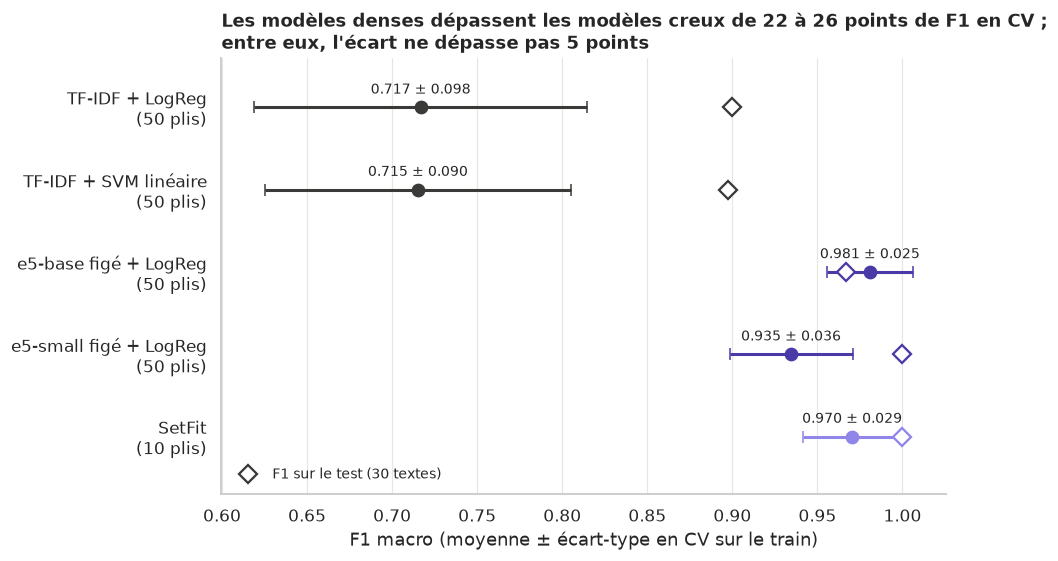

In [30]:
plot_score_intervals(cv_scores[MODEL_NAMES], ("Les modèles denses dépassent les modèles creux de 22 à 26 points de F1 en CV ;\n"
                      "entre eux, l'écart ne dépasse pas 5 points"), "comparaison_modeles", test_scores=test_f1,
                     colors={name: FAMILY_COLORS[FAMILY[name]] for name in MODEL_NAMES})

**Lecture du tableau.**

- **Deux niveaux nets.** En CV (50 plis), les modèles creux sont à 0,72 ± 0,09 ; les modèles
  denses à 0,94-0,98 ± 0,03. Les barres d'erreur ne se chevauchent pas entre familles.
- **Le test à 30 textes brouille le classement fin** : e5-small et SetFit y ont 100 %,
  e5-base 96,7 % (1 erreur) et les modèles creux 90 % (3 erreurs). Les intervalles bootstrap
  (de [0,80 ; 1,00] à [1,00 ; 1,00]) se recouvrent presque tous : seul le classement par
  famille est fiable, pas celui à l'intérieur des familles. Le « 1,00 » d'e5-small ne bat pas
  e5-base (0,981 en CV contre 0,935) : c'est le hasard des 30 textes.
- **Le coût**, lui, ne se discute pas : les modèles creux s'entraînent en 0,05 s et pèsent
  0,3 Mo ; e5-base pèse 1,1 Go de poids et SetFit ajoute 37 s de GPU, pour un gain en CV
  (0,970) qui n'est pas supérieur à celui de l'encodeur figé (0,981 ; 10 plis contre 50,
  donc plus bruité). **Affiner l'encodeur ne rapporte rien ici** : 120 textes ne justifient pas
  de toucher aux 278 M de paramètres.
- **Explicabilité** : seuls les modèles creux montrent mot par mot pourquoi ils décident
  (2.4). C'est ce que l'on sacrifie en choisissant le dense.

**Mémoire en production.** Elle pèse dans le choix final : mesurée plus bas, elle atteint 1,56 Go
pour e5-base et 1,32 Go pour e5-small, dont 0,85 Go pour le seul import de `torch` +
`sentence-transformers`. Seul le modèle creux (0,2 Go) tient dans un budget de ~1 Go. On y revient
dans le choix du modèle.

**Matrices de confusion**, sur le test (30 textes) et sur les prédictions hors-pli des
150 textes (5 plis ; même réglage que le modèle final), plus nombreuses donc plus parlantes.
Lignes = vraie classe, normalisées ; le compte brut est entre parenthèses.

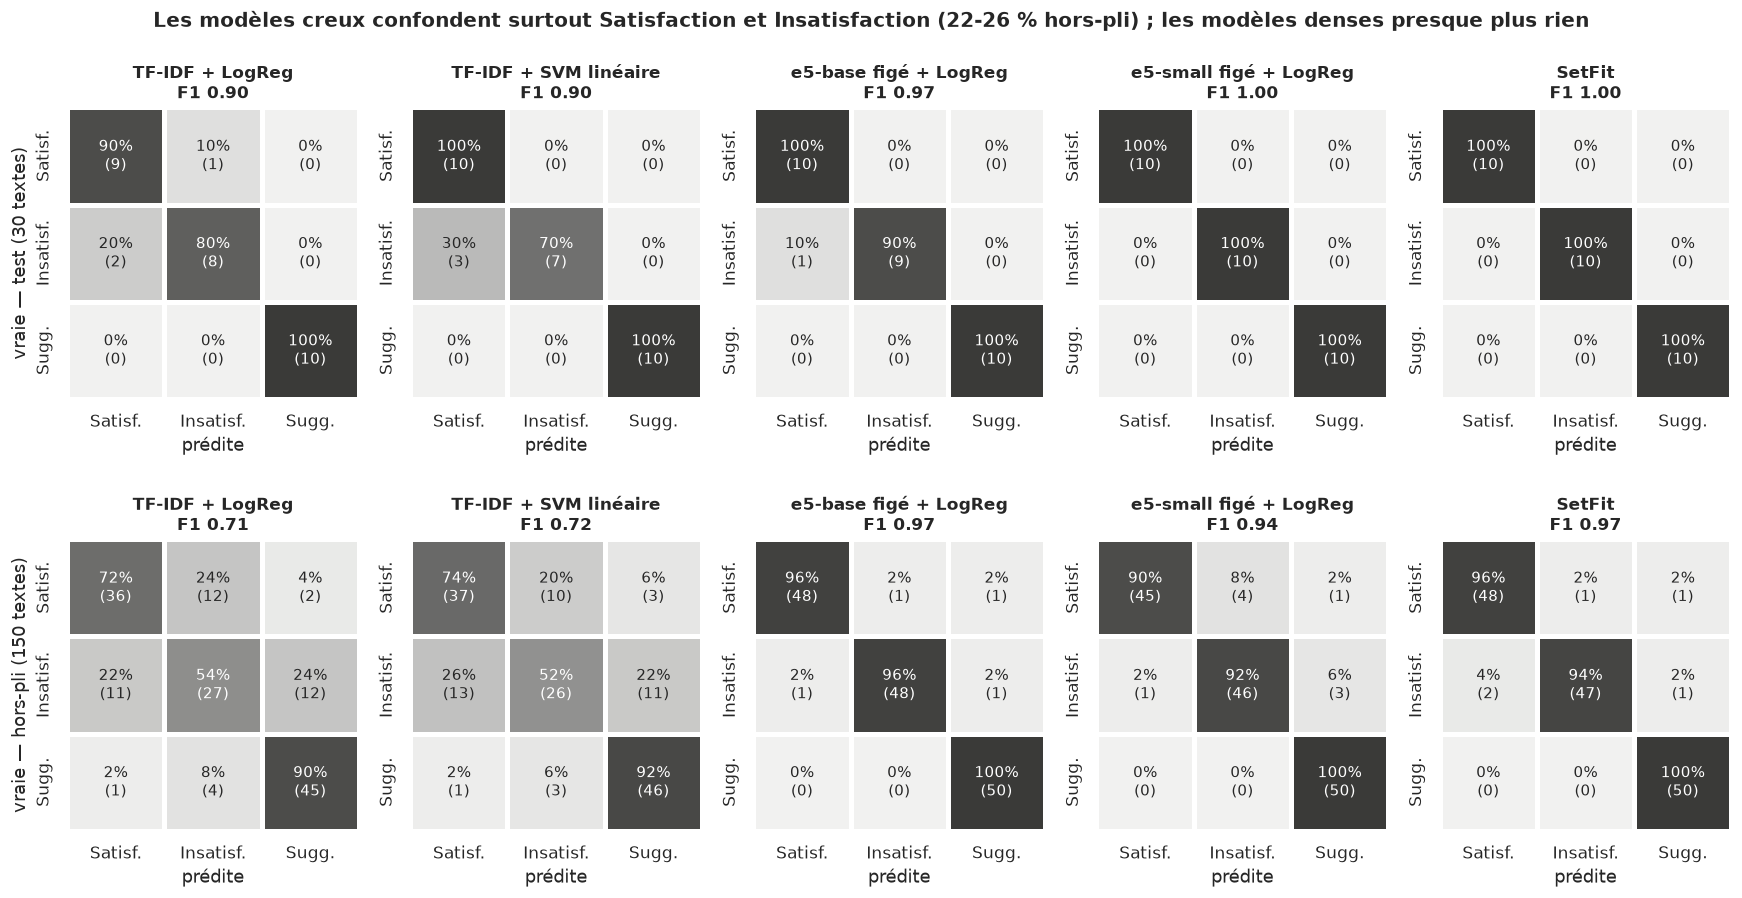

In [31]:
oof_pred = {name: cross_val_predict(model, texts, labels, cv=oof_splitter) for name, model in final_models.items()}
oof_pred["SetFit"] = most_probable(setfit_results["oof_proba"])
PREDICTION_SETS = {"test (30 textes)": (y_test, test_pred), "hors-pli (150 textes)": (labels, oof_pred)}
SHORT_LABELS = ["Satisf.", "Insatisf.", "Sugg."]

fig, axes = plt.subplots(len(PREDICTION_SETS), len(MODEL_NAMES), figsize=(16, 8.4))
for row_axes, (set_name, (y_true, predictions)) in zip(axes, PREDICTION_SETS.items()):
    for ax, name in zip(row_axes, MODEL_NAMES):
        counts = confusion_matrix(y_true, predictions[name], labels=CLASS_ORDER)
        rates = counts / counts.sum(axis=1, keepdims=True)
        annotations = [[f"{rate:.0%}\n({count})" for rate, count in zip(*row)] for row in zip(rates, counts)]
        sns.heatmap(rates, vmin=0, vmax=1, cmap=sns.light_palette("#3a3a38", as_cmap=True), annot=annotations,
                    fmt="", cbar=False, square=True, linewidths=2, linecolor="white",
                    xticklabels=SHORT_LABELS, yticklabels=SHORT_LABELS, annot_kws={"fontsize": 10}, ax=ax)
        ax.set_title(f"{name}\nF1 {f1_macro(y_true, predictions[name]):.2f}", fontsize=11)
        ax.set(xlabel="prédite", ylabel=f"vraie — {set_name}" if ax in row_axes[:1] else "")
        ax.tick_params(left=False, bottom=False)
fig.suptitle("Les modèles creux confondent surtout Satisfaction et Insatisfaction (22-26 % hors-pli) ; "
             "les modèles denses presque plus rien", fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "matrices_confusion.png")
plt.show()

**Lecture.**

- **Test (30 textes) : peu d'erreurs, donc peu d'information.** La régression logistique
  creuse se trompe 3 fois : 1 satisfaction prise pour une insatisfaction, 2 insatisfactions
  prises pour des satisfactions ; le SVM, 3 insatisfactions prises pour des satisfactions.
  Aucune suggestion n'est jamais manquée (10/10) par aucun modèle.
- **Hors-pli (150 textes), le même schéma est net.** Pour la régression logistique creuse,
  **Satisfaction ↔ Insatisfaction concentre l'essentiel des erreurs** : 12 satisfactions
  classées insatisfaites (24 %) et 11 insatisfactions classées satisfaites (22 %), soit 23 des 42
  erreurs. Les insatisfactions sont aussi prises pour des suggestions 12 fois (24 %), alors que la Suggestion
  est la mieux reconnue (90 %, 45/50) : la partie 1 l'expliquait, 98 % des suggestions ont un
  infinitif en tête ou un conditionnel, marqueurs absents des deux autres classes.
- **Pourquoi Satisfaction ↔ Insatisfaction.** Ces deux classes parlent du même thème (dossier,
  délai, formulaire) et ne se distinguent que par la polarité, que le sac de mots lit mal : la
  négation signe 50 % des insatisfactions mais aussi 16 % des satisfactions
  (« aucun problème », « je n'ai attendu que 10 minutes »), et une plainte sans mot négatif
  (« le formulaire en ligne plante ») n'a aucun marqueur lexical.
- **Les modèles denses se trompent 4 fois (e5-base) à 9 fois (e5-small) sur 150**, sans confusion
  dominante : ils lisent le sens de la phrase, pas une liste de mots.

**Le meilleur creux contre le meilleur dense : test de McNemar exact.** On ne compte que
les textes où les deux modèles divergent (l'un juste, l'autre faux) ; sous l'hypothèse
d'égalité, ces désaccords se répartissent à pile ou face.

In [32]:
def mcnemar_exact(y_true, pred_a, pred_b):
    correct_a, correct_b = pred_a == np.asarray(y_true), pred_b == np.asarray(y_true)
    only_a, only_b = int((correct_a & ~correct_b).sum()), int((~correct_a & correct_b).sum())
    p_value = binomtest(only_a, only_a + only_b).pvalue if only_a + only_b else 1.0
    return {"seul A juste": only_a, "seul B juste": only_b, "p-value": f"{p_value:.1e}"}


best_sparse = max((name for name in MODEL_NAMES if FAMILY[name] == "creuse"), key=lambda name: cv_scores[name].mean())
best_dense = max((name for name in MODEL_NAMES if FAMILY[name] != "creuse"), key=lambda name: cv_scores[name].mean())
print(f"A = {best_sparse}, B = {best_dense}")
pd.DataFrame({set_name: mcnemar_exact(y_true, predictions[best_sparse], predictions[best_dense])
              for set_name, (y_true, predictions) in PREDICTION_SETS.items()}).T

A = TF-IDF + LogReg, B = e5-base figé + LogReg


,seul A juste,seul B juste,p-value
test (30 textes),0,2,5.0e-01
hors-pli (150 textes),0,38,7.3e-12


**Conclusion du test : la différence est réelle sur 150 textes, pas démontrable sur 30.**

- Sur les **150 prédictions hors-pli** : e5-base a raison seul sur 38 textes, la régression
  logistique creuse sur 0 (p ≈ 7·10⁻¹², très significatif). Tout ce que le creux réussit,
  le dense le réussit aussi.
- Sur les **30 textes du test** : 2 contre 0, p = 0,5 : le test ne peut tout simplement pas
  trancher avec si peu de désaccords. C'est la limite annoncée en 2.1, pas un contre-argument.
- **Ce n'est donc pas un cas « scores proches ».** L'écart est de 26 points de F1 en CV et le
  test apparié le confirme : le modèle dense est meilleur. La question du choix n'est plus la
  précision mais le coût (mémoire, explicabilité).

**Faut-il plus de données ?** Courbe d'apprentissage sur le train (5 plis × 5 répétitions) :
F1 macro de validation en fonction du nombre de textes d'entraînement.

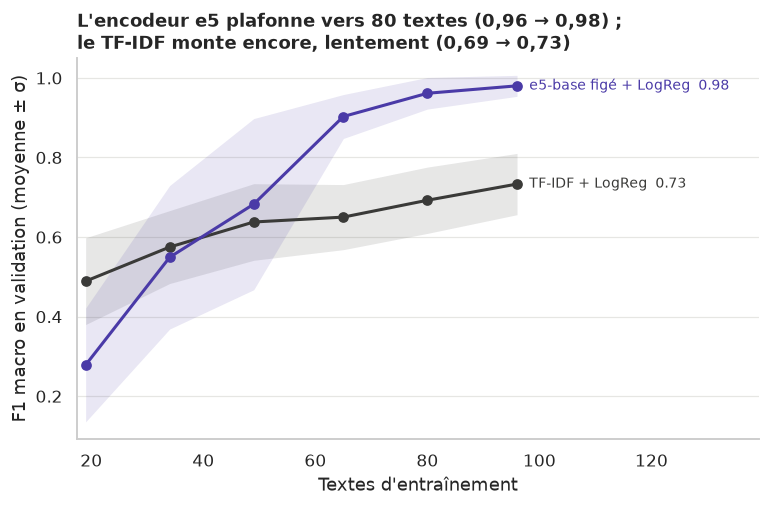

In [33]:
LEARNING_CURVE_MODELS = ["TF-IDF + LogReg", "e5-base figé + LogReg"]
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in LEARNING_CURVE_MODELS:
    sizes, _, validation_scores = learning_curve(
        final_models[name], X_train, y_train, train_sizes=np.linspace(0.2, 1, 6), scoring="f1_macro",
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED), shuffle=True, random_state=SEED)
    mean, std = validation_scores.mean(axis=1), validation_scores.std(axis=1)
    color = FAMILY_COLORS[FAMILY[name]]
    ax.plot(sizes, mean, marker="o", color=color, linewidth=2)
    ax.fill_between(sizes, mean - std, mean + std, color=color, alpha=0.12, linewidth=0)
    ax.annotate(f"{name}  {mean[-1]:.2f}", (sizes[-1], mean[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color=color)
ax.set(xlabel="Textes d'entraînement", ylabel="F1 macro en validation (moyenne ± σ)")
ax.margins(x=0.02)
ax.set_xlim(right=sizes[-1] * 1.45)
ax.grid(axis="x", visible=False)
ax.set_title("L'encodeur e5 plafonne vers 80 textes (0,96 → 0,98) ;\n"
             "le TF-IDF monte encore, lentement (0,69 → 0,73)", loc="left")
fig.savefig(FIGURES_DIR / "courbe_apprentissage.png")
plt.show()

**Lecture.**

- **e5 + régression logistique** : sous 40 textes il est battu par le TF-IDF (0,28 à 20 textes,
  0,55 à 34), il dépasse le creux vers 40 textes, atteint 0,90 à 65, puis 0,96 à 80 et
  0,98 à 96 : la courbe s'aplatit, **plus de données apporteraient peu** (≈ +1 point).
- **TF-IDF** : 0,49 → 0,73, sans plateau net mais à pente faible (≈ +4 points par tranche de
  15 textes) ; même avec 3 à 4 fois plus de données, rien ne laisse espérer qu'il rattrape
  l'encodeur : ses limites sont structurelles (polarité invisible à un sac de mots).
- **Les bandes ±σ sont larges** (±0,1 pour le creux) : la courbe est indicative, pas précise.

**Choix du modèle.** Le choix suit les chiffres, non l'élégance :

- **Retenu : `e5-base` figé + régression logistique.** Meilleur F1 CV (0,981 ± 0,025), 1 seule
  erreur au test, 4 erreurs hors-pli sur 150, significativement meilleur que le creux (McNemar).
  Par rapport à SetFit (0,970), il est aussi bon (écart non significatif), s'entraîne en 1 s au
  lieu de 37 s et n'exige pas de GPU.
- **Réserve de déploiement** : e5-base consomme 1,56 Go de RAM sur CPU (dont 0,85 Go pour
  `torch`), au-delà du ~1 Go souvent garanti par les hébergeurs gratuits. L'application
  est déployée sur **Streamlit Community Cloud** (`deploy/streamlit/`, torch CPU sans CUDA ; Hugging Face Spaces
  exige désormais un abonnement pour Streamlit) ; si la mémoire manque, son sélecteur bascule sur le TF-IDF. Autres parades : e5-small (1,32 Go, 4 points de moins en CV : 0,935) ou un encodeur exporté en ONNX quantifié.
- **Repli exporté : TF-IDF + régression logistique** (0,2 Go, 0,3 Mo, explicable, 0,717 en
  CV). C'est le plan B s'il faut tenir 1 Go : il se trompe une fois sur quatre entre
  Satisfaction et Insatisfaction, ce que l'application devrait signaler.

Les deux sont exportés dans `models/`. Pour e5, on ne sérialise que la tête
(`models/e5_logreg.joblib`, quelques Ko) ; l'encodeur est rechargé par son nom.

In [34]:
# Les scores rapportés sont ceux des modèles entraînés sur le train ; les modèles exportés gardent leurs
# hyperparamètres mais apprennent sur les 150 textes (la courbe d'apprentissage monte encore).
RETAINED_MODEL = "e5-base figé + LogReg"
RETAINED_PATH = MODELS_DIR / "e5_logreg.joblib"
FALLBACK_MODEL = "TF-IDF + LogReg"
FALLBACK_PATH = MODELS_DIR / "tfidf_logreg.joblib"

# Seule la tête est sérialisée : l'application recharge l'encodeur figé par son nom (cache Hugging Face).
retained_head = clone(final_models[RETAINED_MODEL].named_steps["clf"]).fit(embed(texts, "e5-base"), labels)
joblib.dump({"encoder": E5_CHECKPOINTS["e5-base"], "prefix": "query: ", "classifier": retained_head}, RETAINED_PATH)
joblib.dump(clone(final_models[FALLBACK_MODEL]).fit(texts, labels), FALLBACK_PATH)

# Vérification de bout en bout comme dans l'application : ré-encodage à neuf (sans le cache) puis prédiction.
exported = joblib.load(RETAINED_PATH)
fresh_embeddings = encoder.encode([exported["prefix"] + text for text in X_test], normalize_embeddings=True,
                                  show_progress_bar=False)
assert (exported["classifier"].predict(fresh_embeddings) == retained_head.predict(embed(X_test, "e5-base"))).all()
for path in [RETAINED_PATH, FALLBACK_PATH]:
    print(f"{path} : {path.stat().st_size / 1e6:.2f} Mo")

models/e5_logreg.joblib : 0.01 Mo
models/tfidf_logreg.joblib : 0.33 Mo


**Ce que coûte chaque modèle dans l'application** : pic de RAM d'un processus Python neuf qui
charge le modèle sur CPU et classe un texte, comme le ferait Streamlit.

In [35]:
def peak_ram_mb(snippet):
    # VmHWM (pic de RAM résidente du processus) : ru_maxrss hériterait du pic du notebook parent.
    script = f"{snippet}\nprint([l for l in open('/proc/self/status') if l.startswith('VmHWM')][0].split()[1])"
    result = subprocess.run([sys.executable, "-c", script], capture_output=True, text=True, check=True,
                            env={**os.environ, "CUDA_VISIBLE_DEVICES": ""})
    return int(result.stdout.split()[-1]) / 1024  # Kio → Mo


def encoder_snippet(checkpoint):
    return (f"from sentence_transformers import SentenceTransformer\n"
            f"SentenceTransformer('{checkpoint}', device='cpu').encode(['query: test'])")


ram_snippets = {
    "TF-IDF + LogReg (joblib exporté)": f"import joblib\njoblib.load('{FALLBACK_PATH}').predict(['test'])",
    "import torch + sentence-transformers seul": "import sentence_transformers",
    "e5-small figé + LogReg": encoder_snippet(E5_CHECKPOINTS["e5-small"]),
    "e5-base figé + LogReg": encoder_snippet(E5_CHECKPOINTS["e5-base"]),
    "SetFit (même architecture mpnet-base)": encoder_snippet(SETFIT_CHECKPOINT),
}
pd.Series({name: round(peak_ram_mb(snippet)) for name, snippet in ram_snippets.items()}, name="pic de RAM (Mo)").to_frame()

,pic de RAM (Mo)
TF-IDF + LogReg (joblib exporté),199
import torch + sentence-transformers seul,846
e5-small figé + LogReg,1315
e5-base figé + LogReg,1554
SetFit (même architecture mpnet-base),1560


### 2.4 Analyse des erreurs

Le test ne contient que quelques erreurs ; on analyse surtout les **prédictions hors-pli**
des 150 textes (chaque texte prédit par un modèle qui ne l'a pas vu).

In [36]:
oof_errors = pd.DataFrame({name: oof_pred[name] != labels.to_numpy() for name in MODEL_NAMES}, index=df.index)
print("Erreurs hors-pli par modèle :", oof_errors.sum().to_dict())
print("Erreurs sur le test :", {name: int((test_pred[name] != y_test.to_numpy()).sum()) for name in MODEL_NAMES})
error_table = df[["id", "categorie", "texte"]].assign(
    **{name: np.where(oof_errors[name], oof_pred[name], "·") for name in MODEL_NAMES},
    n_modeles_faux=oof_errors.sum(axis=1))
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(error_table[error_table["n_modeles_faux"] > 0].sort_values(["n_modeles_faux", "id"], ascending=[False, True]))

Erreurs hors-pli par modèle : {'TF-IDF + LogReg': 42, 'TF-IDF + SVM linéaire': 41, 'e5-base figé + LogReg': 4, 'e5-small figé + LogReg': 9, 'SetFit': 5}
Erreurs sur le test : {'TF-IDF + LogReg': 3, 'TF-IDF + SVM linéaire': 3, 'e5-base figé + LogReg': 1, 'e5-small figé + LogReg': 0, 'SetFit': 0}


,id,categorie,texte,TF-IDF + LogReg,TF-IDF + SVM linéaire,e5-base figé + LogReg,e5-small figé + LogReg,SetFit,n_modeles_faux
4,5,Insatisfaction,Le formulaire en ligne plante au moment de la soumission.,Satisfaction,Satisfaction,Suggestion,Suggestion,Satisfaction,5
46,47,Satisfaction,Je n'ai attendu que 10 minutes avant d'être pris en charge.,Insatisfaction,Insatisfaction,Insatisfaction,Insatisfaction,Insatisfaction,5
77,78,Satisfaction,La clarté des informations fournies facilite les démarches.,Insatisfaction,Insatisfaction,Suggestion,Suggestion,·,4
11,12,Insatisfaction,Traitement discriminatoire selon la tête du client.,Suggestion,Suggestion,·,Suggestion,·,3
14,15,Insatisfaction,J'ai dû payer un intermédiaire pour que mon dossier avance.,·,Suggestion,·,Suggestion,Suggestion,3
49,50,Insatisfaction,Je n'ai reçu aucun accusé de réception de ma demande.,Satisfaction,Satisfaction,Satisfaction,·,·,3
74,75,Satisfaction,"Service de première classe, je n'ai aucune remarque négative.",Insatisfaction,Insatisfaction,·,Insatisfaction,·,3
102,103,Insatisfaction,Le délai de 7 jours annoncé s'est transformé en 2 mois.,Satisfaction,Satisfaction,·,·,Satisfaction,3
111,112,Satisfaction,Mon problème a été résolu en une seule visite.,Insatisfaction,Insatisfaction,·,Insatisfaction,·,3
0,1,Insatisfaction,Manque total de communication entre les services.,Suggestion,Suggestion,·,·,·,2


Sur 150 textes, la régression logistique creuse se trompe 42 fois, e5-base 4, SetFit 5. Le tableau
ci-dessus classe les erreurs par nombre de modèles fautifs. On en détaille cinq, choisis
parce qu'ils correspondent à cinq mécanismes différents ; tous sont des erreurs hors-pli de la
régression logistique creuse :

| id | piège | modèles faux |
|---|---|---|
| 47 | négation à sens positif (« n'ai attendu **que** 10 minutes ») | tous les 5 |
| 50 | négation noyée par le verbe (« n'ai reçu **aucun** accusé ») | 3 : creux (2) + e5-base |
| 5 | plainte sans vocabulaire négatif (« le formulaire en ligne **plante** ») | tous les 5 |
| 78 | **temps du verbe** : la jumelle de l'id 42 (« faciliterait » → Suggestion, juste) | creux (2) + e5-base + e5-small |
| 127 | paire thématique 127 / 101 « langue locale » | creux (2) uniquement |

L'id 73 (éwé) est reconnu par le creux grâce au glossaire (`nyuie` → `bien`, P = 0,99) et manqué
par SetFit seul : la stratégie éwé de la partie 1 joue son rôle. L'id 131 (éwé, insatisfaction), le
piège de la partie 1, est correctement classé par tous les modèles hors-pli : une fois « ne pas »
restitué par le glossaire, les mots `mele`, `ne`, `pas` suffisent au modèle creux.

In [37]:
ERROR_IDS = [47, 50, 5, 78, 127]
oof_proba_logreg = pd.DataFrame(cross_val_predict(final_models[FALLBACK_MODEL], texts, labels, cv=oof_splitter,
                                                  method="predict_proba"),
                                columns=final_models[FALLBACK_MODEL].classes_, index=df["id"])[CLASS_ORDER]
with pd.option_context("display.max_colwidth", None):
    display(error_table.set_index("id").loc[ERROR_IDS].join(oof_proba_logreg.round(2).add_prefix("P LogReg ")))

,categorie,texte,TF-IDF + LogReg,TF-IDF + SVM linéaire,e5-base figé + LogReg,e5-small figé + LogReg,SetFit,n_modeles_faux,P LogReg Satisfaction,P LogReg Insatisfaction,P LogReg Suggestion
id,,,,,,,,,,,
47,Satisfaction,Je n'ai attendu que 10 minutes avant d'être pris en charge.,Insatisfaction,Insatisfaction,Insatisfaction,Insatisfaction,Insatisfaction,5,0.09,0.90,0.01
50,Insatisfaction,Je n'ai reçu aucun accusé de réception de ma demande.,Satisfaction,Satisfaction,Satisfaction,·,·,3,0.76,0.23,0.02
5,Insatisfaction,Le formulaire en ligne plante au moment de la soumission.,Satisfaction,Satisfaction,Suggestion,Suggestion,Satisfaction,5,0.75,0.11,0.14
78,Satisfaction,La clarté des informations fournies facilite les démarches.,Insatisfaction,Insatisfaction,Suggestion,Suggestion,·,4,0.04,0.62,0.34
127,Insatisfaction,Aucune version en langue locale disponible pour les non-francophones.,Suggestion,Suggestion,·,·,·,2,0.00,0.20,0.80


**Contributions mot par mot.** Pour la régression logistique creuse, l'écart de logit entre
deux classes est une somme exacte de termes coefficient × TF-IDF. On répartit chaque
n-gramme entre les mots qui le portent (un bigramme entre ses deux mots, un n-gramme de
caractères entre les mots qui le contiennent) : chaque barre dit de combien ce mot pousse
vers la classe prédite à tort (à droite) ou vers la vraie classe (à gauche). Le modèle
utilisé est celui du pli où le texte était hors entraînement, celui qui s'est trompé.

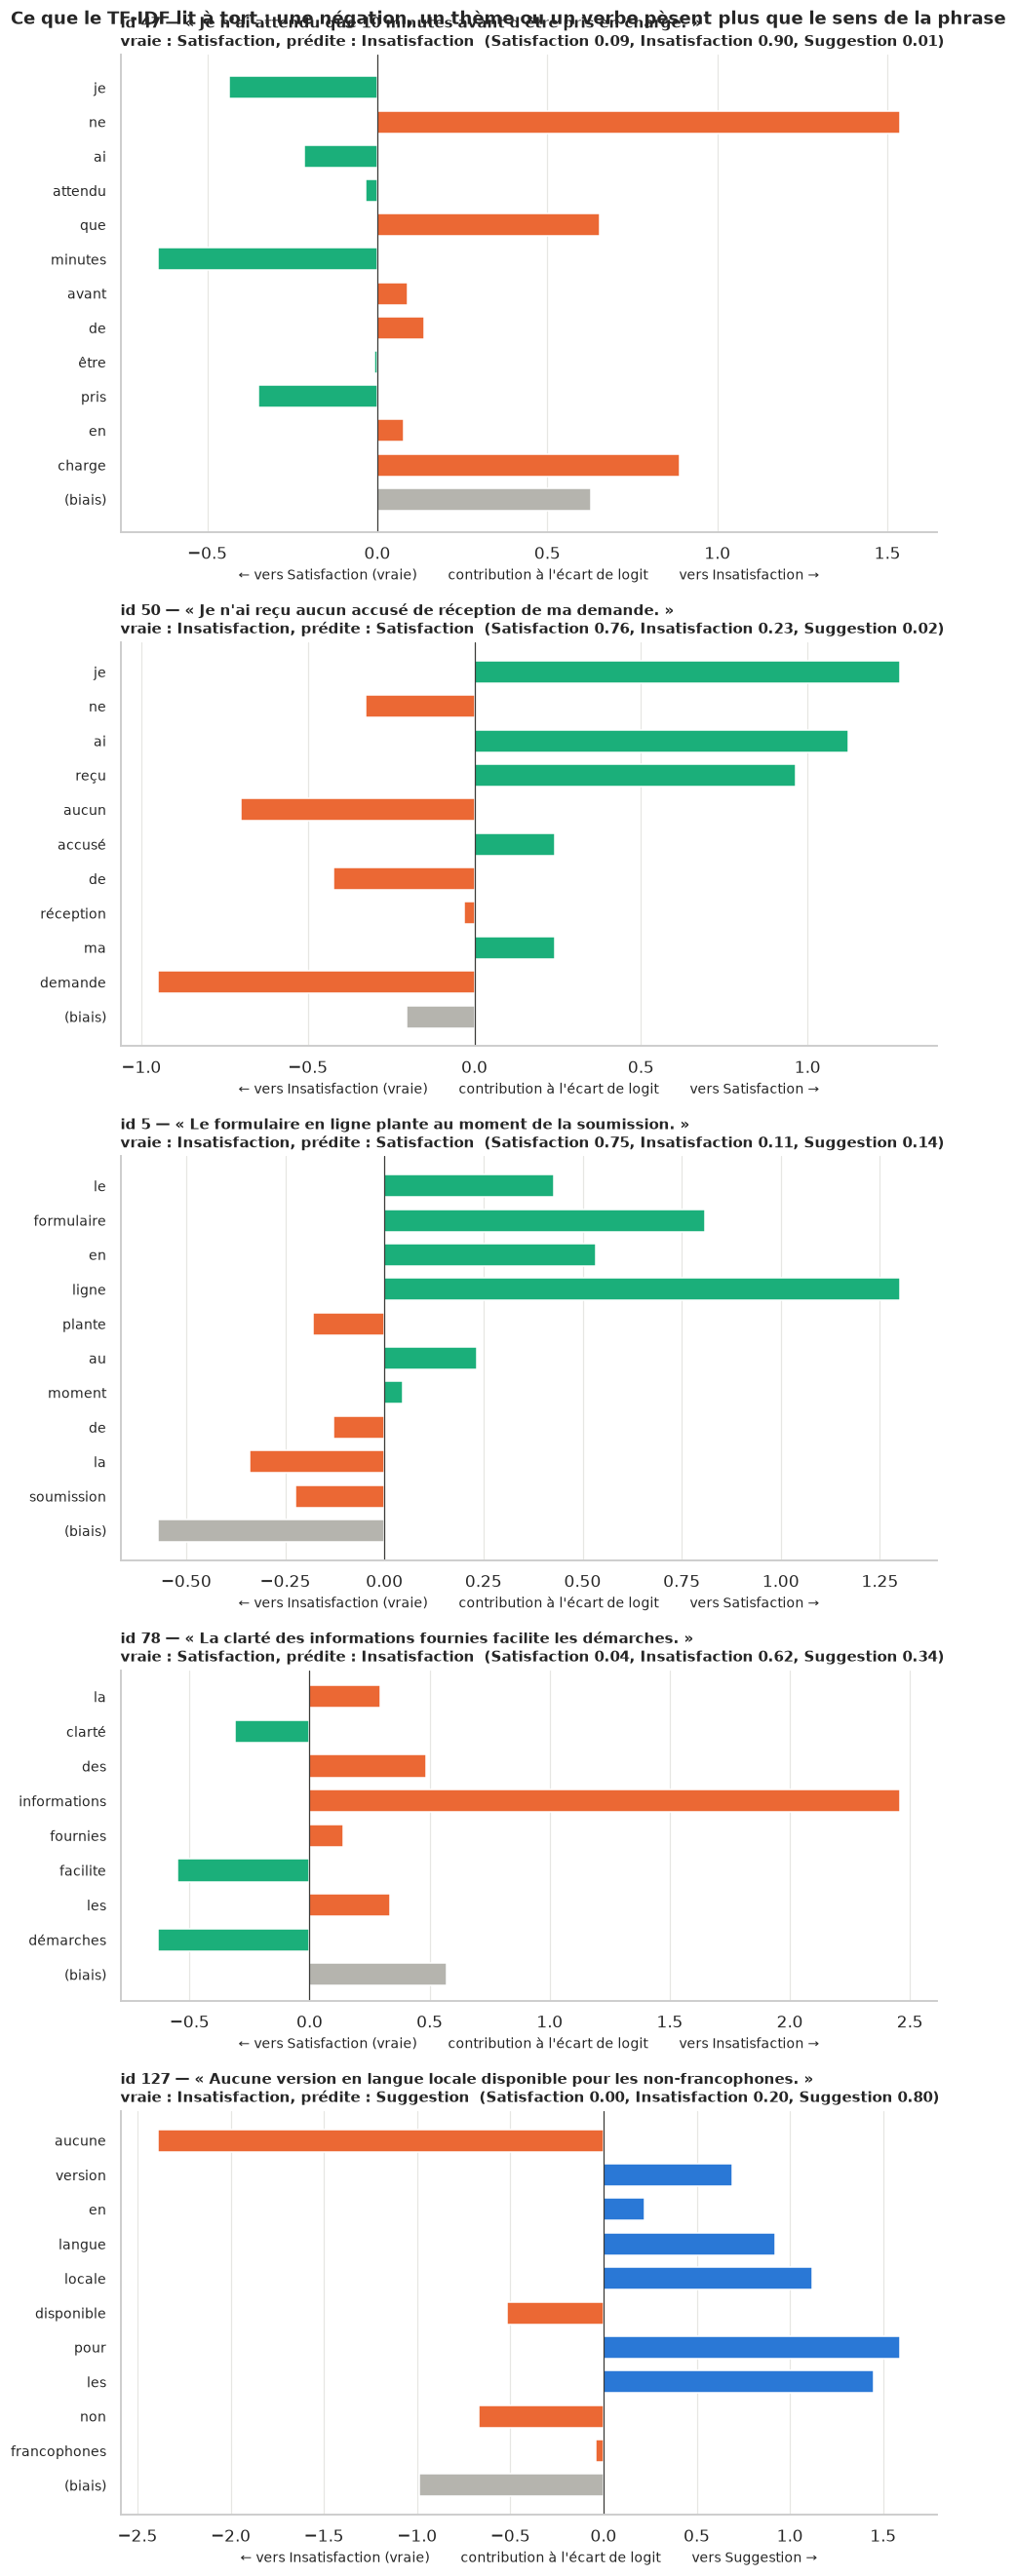

In [38]:
def model_without(row_index):
    """Ré-entraîne le modèle retenu sur le pli hors-pli qui excluait ce texte (déterministe : mêmes prédictions)."""
    train_part = next(train for train, held_out in oof_splitter.split(texts, labels) if row_index in held_out)
    return clone(final_models[FALLBACK_MODEL]).fit(texts.iloc[train_part], labels.iloc[train_part])


def word_contributions(text, model, toward, against):
    union, logreg = model.named_steps["features"], model.named_steps["clf"]
    classes = list(logreg.classes_)
    coef_gap = logreg.coef_[classes.index(toward)] - logreg.coef_[classes.index(against)]
    weight_by_feature = dict(zip(union.get_feature_names_out(), coef_gap * union.transform([text]).toarray()[0]))
    words = clean_text(text).split()
    owners = defaultdict(list)  # n-gramme → mots qui le portent
    for prefix, vectorizer in union.transformer_list:
        analyze = vectorizer.build_analyzer()
        for word in words:
            for gram in analyze(word):
                owners[f"{prefix}__{gram}"].append(word)
    for bigram in union.named_transformers["mots"].build_analyzer()(text):
        if " " in bigram:  # partagé entre ses deux mots
            owners[f"mots__{bigram}"].extend(bigram.split())
    contributions = dict.fromkeys(words, 0.0)
    for feature, owner_words in owners.items():
        for word in owner_words:
            contributions[word] += weight_by_feature.get(feature, 0.0) / len(owner_words)
    contributions["(biais)"] = logreg.intercept_[classes.index(toward)] - logreg.intercept_[classes.index(against)]
    logits = dict(zip(classes, model.decision_function([text])[0]))
    assert np.isclose(sum(contributions.values()), logits[toward] - logits[against]), "décomposition inexacte"
    return pd.Series(contributions)


def plot_word_contributions(ax, comment_id):
    row = df.loc[df["id"] == comment_id].iloc[0]
    model = model_without(row.name)
    proba = pd.Series(model.predict_proba([row["texte"]])[0], index=model.classes_)
    true_class, rival_class = row["categorie"], proba.drop(row["categorie"]).idxmax()
    contributions = word_contributions(row["texte"], model, toward=rival_class, against=true_class)
    colors = [CLASS_COLORS[rival_class] if value > 0 else CLASS_COLORS[true_class] for value in contributions]
    colors[-1] = "#b5b4ae"  # biais : propre au modèle, pas au texte
    ax.barh(range(len(contributions)), contributions.values, color=colors, height=0.65)
    ax.set_yticks(range(len(contributions)), contributions.index, fontsize=9)
    ax.invert_yaxis()  # ordre de lecture de la phrase
    ax.axvline(0, color="#3a3a38", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(f"← vers {true_class} (vraie)        contribution à l'écart de logit        vers {rival_class} →",
                  fontsize=9)
    probabilities = ", ".join(f"{label} {proba[label]:.2f}" for label in CLASS_ORDER)
    ax.set_title(f"id {comment_id} — « {textwrap.shorten(row['texte'], 75)} »\n"
                 f"vraie : {true_class}, prédite : {proba.idxmax()}  ({probabilities})", loc="left", fontsize=10)


n_bars = [len(dict.fromkeys(clean_text(df.loc[df["id"] == comment_id, "texte"].iloc[0]).split())) + 1
          for comment_id in ERROR_IDS]
fig, axes = plt.subplots(len(ERROR_IDS), 1, figsize=(9, 0.3 * sum(n_bars) + 1.6 * len(ERROR_IDS)),
                         gridspec_kw={"height_ratios": n_bars})
for ax, comment_id in zip(axes, ERROR_IDS):
    plot_word_contributions(ax, comment_id)
fig.suptitle("Ce que le TF-IDF lit à tort : une négation, un thème ou un verbe pèsent plus que le sens de la phrase",
             fontweight="bold", fontsize=12, x=0.02, ha="left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "erreurs_contributions.png")
plt.show()

**Analyse des cinq exemples** (barres vertes/orange/bleues : vers Satisfaction/Insatisfaction/Suggestion).

- **id 47, « Je n'ai attendu que 10 minutes… » (Satisfaction → Insatisfaction, P = 0,90).**
  Le mot « ne » pèse à lui seul +1,5 en faveur d'Insatisfaction (9 occurrences en
  Insatisfaction contre 2 et 1 ailleurs, partie 1) et « charge » et « que » ajoutent
  +0,9 et +0,7 ; « minutes » (-0,6) et « je » (-0,4) ne compensent pas. Le modèle n'a aucun
  moyen de savoir que « ne… que » signifie « seulement » : **la restriction positive est
  indiscernable de la négation**. Les quatre autres modèles se trompent aussi : même un
  encodeur lisant toute la phrase prend cette tournure pour une plainte sur l'attente.
- **id 50, « Je n'ai reçu aucun accusé… » (Insatisfaction → Satisfaction, P = 0,76).**
  L'erreur inverse : « ne » (-0,3), « aucun » (-0,7) et « demande » (-0,9) vont dans le bon sens,
  mais « je » (+1,3), « ai » (+1,1) et « reçu » (+1,0) l'emportent. Dans le train, « je »
  apparaît dans 10 satisfactions contre 3 insatisfactions, « ai » dans 6 contre 3, et « reçu »
  uniquement dans « J'ai reçu mon document dans les délais » (id 142, Satisfaction) :
  **le modèle associe « j'ai reçu » aux satisfactions**, avec un seul exemple à l'appui. Il voit
  le verbe, pas le « aucun » qui inverse tout ; un mot vu une fois suffit à faire basculer
  un texte de 10 mots.
- **id 5, « Le formulaire en ligne plante… » (Insatisfaction → Satisfaction, P = 0,75).**
  « ligne » (+1,3), « formulaire » (+0,8) et « en » (+0,5) tirent vers Satisfaction (« le formulaire
  en ligne est intuitif » est une satisfaction du corpus) ; « plante », absent de tout autre
  texte du corpus, ne pèse que -0,2 par ses n-grammes de caractères. **Le vocabulaire du thème
  l'emporte sur un verbe d'échec jamais vu.** SetFit se trompe aussi (Satisfaction), e5-base et
  e5-small prédisent Suggestion.
- **id 78, « La clarté des informations… facilite les démarches » (Satisfaction → Insatisfaction,
  P = 0,62).** La jumelle de l'id 42 (« …faciliterait les démarches », Suggestion, classée
  juste à P = 0,97). Ici « informations » pèse +2,5 vers Insatisfaction (c'est un mot de
  plainte dans le train : « informations erronées », « informations obsolètes ») et écrase
  « facilite » (-0,6) et « démarches » (-0,6). **Le seul indice du temps, `facilite` contre
  `faciliterait`, ne tient qu'à un suffixe (`rait`) que les n-grammes de caractères voient,
  mais le mot voisin « informations » le noie** : dans le train, il n'apparaît que dans deux
  insatisfactions (« informations erronées », « informations obsolètes »). L'id 42 était bien classé
  grâce à `rait` ; l'indicatif, lui, n'a pas de marqueur propre : il ne se définit que par
  l'absence de conditionnel.
- **id 127, « Aucune version en langue locale disponible… » (Insatisfaction → Suggestion,
  P = 0,80).** « aucune » (-2,4) fait ce qu'il faut, mais « pour » (+1,6), « les » (+1,4),
  « locale » (+1,1), « langue » (+0,9) et « version » (+0,7) forment le vocabulaire de la
  suggestion jumelle id 101 (« Il serait bien d'avoir une version du site en langue locale ») et
  des phrases en « pour les ». Aucun conditionnel ni infinitif n'est pourtant présent : **le thème
  et deux mots-outils ont pris le pas sur l'absence de la forme propre à la Suggestion**.
  e5 et SetFit, qui lisent l'intention, ne se trompent pas.

**Typologie des erreurs et correctifs.**

| Type | Exemples | Ce qui le corrigerait |
|---|---|---|
| **Polarité inversée par la négation** | 47, 50 | modèle qui lit la phrase entière (embeddings : ces cas restent difficiles même pour eux : 47 est faux pour les 5 modèles) ; ou règle de portée de la négation (« ne… que » = restriction) |
| **Plainte sans mot de plainte** | 5 | plus de données avec des verbes d'échec (« plante », « bloque ») ; embeddings, qui généralisent « plante » par le sens |
| **Indice grammatical noyé par le thème** | 78, 127 | traits explicites de forme (infinitif/conditionnel en tête, voir partie 1) en plus du sac de mots ; paires minimales (42/78, 101/127) ajoutées à l'entraînement |
| **Éwé hors vocabulaire du modèle** | 73 (SetFit seul ; aussi CamemBERT en 4.2) | glossaire validé et élargi par un locuteur (partie 1) |

Les cinq modèles ne se trompent ensemble que sur les ids 47 et 5 : les deux erreurs qu'aucune
représentation de ce corpus ne corrige. Pour le reste, le dense rattrape ce que le TF-IDF rate
parce qu'il lit le sens plutôt que les mots.

## 3. Conclusion, limites et pistes

### Synthèse chiffrée

| Modèle | F1 macro CV (± σ) | F1 macro test (30 textes) | Erreurs hors-pli (/150) | Coût |
|---|---|---|---|---|
| TF-IDF + régression logistique | 0,717 ± 0,098 | 0,90 (3 erreurs) | 42 | 0,05 s, 0,3 Mo, 0,2 Go de RAM |
| **e5-base figé + régression logistique (retenu)** | **0,981 ± 0,025** | **0,967 (1 erreur)** | **4** | 1 s, 1,1 Go de poids, 1,56 Go de RAM |
| SetFit | 0,970 (10 plis) | 1,00 | 5 | 37 s de GPU |

- **Le gain vient de la représentation, pas du réglage** : 26 points de F1 entre sac de mots et
  encodeur pré-entraîné, alors que stopwords, n-grammes ou `C` ne déplacent le score creux que
  de 2 à 4 points, sous le bruit entre plis. Les marqueurs de forme (infinitif, conditionnel,
  négation) sont lisibles par un sac de mots ; la polarité, non.
- **Affiner l'encodeur (SetFit) ne rapporte rien** à 120 textes, et la courbe d'apprentissage d'e5 est plate vers 80 textes.
- **Les erreurs restantes sont de la sémantique fine** : négation à sens positif (id 47, faux pour
  les 5 modèles), plainte sans mot de plainte (id 5), temps du verbe (78 contre 42), paire thématique 127 / 101.

### Limites

1. **Un corpus de 150 textes très « gabarit »** : phrases courtes, formes répétées (« Il serait bien de… »,
   « Envoyer des SMS… »), un thème par texte. Les 0,98 mesurés sont **probablement optimistes** :
   de vrais commentaires (fautes, phrases longues, ironie, plusieurs sujets) seront plus durs. Aucune
   validation sur des données réelles n'a été faite.
2. **Un test de 30 textes** : une erreur vaut 3,3 points d'accuracy et les intervalles bootstrap
   se recouvrent presque tous. Seul l'écart creux/dense est établi (hors-pli, McNemar), pas le classement
   entre e5-base, e5-small et SetFit ; d'où le recours à la validation croisée répétée.
3. **L'éwé est quasi absent : 3 textes sur 150** (ids 73, 131, 139). Le glossaire additif n'est donc
   validé que sur 3 exemples du corpus (plus 15 textes mixtes rédigés en 4.1) et ne mesure aucune capacité réelle en éwé. Il traduit **mot à mot, sans
   désambiguïsation** : `mele` devient « ne pas » alors qu'il signifie aussi « je suis » (la
   négation vient de la particule finale « o »), `hafi` devient « vraiment » alors qu'il signifie
   « avant », et le pluriel `-wo` n'est pas reconnu. Des erreurs de glose sont donc possibles sur de nouveaux textes. `multilingual-e5`
   couvre mal l'éwé : ces mots sont mal représentés par l'encodeur.
4. **Une seule étiquette par texte**, alors qu'un vrai retour mêle souvent plainte et suggestion
   (« Le dossier a mis 3 mois, il faudrait un suivi en ligne »). Le modèle est forcé de choisir.
5. **Probabilités non calibrées** : la régression logistique sur 768 dimensions dit rarement « je ne sais pas ».
   Pour le déploiement, e5-base demande 1,56 Go de RAM (repli TF-IDF disponible, 0,717 de F1).

### Pistes, par ordre de priorité

1. **Collecter et annoter de vrais retours citoyens** (quelques centaines), avec **double annotation** et
   mesure de l'accord (kappa de Cohen) : c'est la seule façon de savoir si 0,98 se généralise, et
   la condition de toutes les autres pistes. Inclure volontairement des textes éwé/mina, des négations
   piégées et des paires minimales (comme 42 / 78 et 101 / 127).
2. **Passer en multi-label** (plainte et suggestion cochables ensemble) : règle la limite 4 et se
   prête à la même base e5 avec une tête sigmoïde.
3. **Un encodeur qui couvre l'éwé** (AfroXLMR, Serengeti, ou affinage de XLM-R sur un corpus
   éwé-français) à comparer à e5 sur le jeu annoté de la piste 1 ; remplacerait le glossaire mot à mot.
4. **Élargir et faire valider le glossaire par un locuteur**, avec lemmatisation (pluriels `-wo`) et choix de la
   glose selon le contexte (`mele`, `hafi`) : peu coûteux, c'est le moyen le plus direct de réduire les erreurs de glose.
5. **Calibrer les probabilités** (régression isotonique ou scaling de température, sur un jeu de validation
   séparé) et **renvoyer à un humain** les textes dont la confiance est faible ; **active learning** : annoter
   en priorité ces textes ambigus, qui sont les plus informatifs.

## 4. Bonus

### 4.1 Commentaires mixtes français / éwé-mina

Les 150 textes ne contiennent que 3 insertions éwé : impossible d'y mesurer l'effet du glossaire.
`test_mixte_fr_ewe.csv` ajoute **15 textes mixtes** (5 par classe), rédigés pour ce test et relus par un
locuteur éwé. La colonne `note` indique si le mot éwé porteur du sens est dans le glossaire
(`glossaire`, 7 textes) ou non (`hors_glossaire:<mot>`, 8 textes), suivie de la traduction.

On compare chaque modèle final (entraîné sur les 120 textes du train) **sans** et **avec** glossaire :

- **TF-IDF + LogReg** : le même pipeline ré-entraîné avec `clean_text(..., use_glossary=False)` ;
- **e5-base figé et SetFit**, qui lisent le texte brut : la variante « avec » ajoute en fin de texte,
  entre parenthèses, les gloses françaises des mots reconnus (« Lala geɖe, nublanui. (attendre attente,
  beaucoup, dommage triste) »). Le texte original reste intact, comme dans le glossaire additif de
  `clean_text`, et la tête de classification n'est pas ré-entraînée : seule l'entrée change. SetFit est
  relu dans `models/setfit/` (pas de ré-entraînement) s'il est présent.

In [39]:
def with_glosses(text):
    glosses = [EWE_LOOKUP[glossary_key(word)] for word in clean_text(text, use_glossary=False).split()
               if glossary_key(word) in EWE_LOOKUP]
    return f"{text} ({', '.join(glosses)})" if glosses else text


mixed = pd.read_csv("test_mixte_fr_ewe.csv")
mixed["groupe"] = np.where(mixed["note"].str.startswith("hors_glossaire"), "hors_glossaire", "glossaire")
glossed = mixed["texte"].map(with_glosses)

tfidf_no_glossary = clone(final_models[FALLBACK_MODEL]).set_params(
    features__mots__tokenizer=partial(tokenize, stop_words=frozenset(), use_glossary=False),
    features__caracteres__preprocessor=partial(clean_text, use_glossary=False)).fit(X_train, y_train)
mixed_pred = {
    ("TF-IDF + LogReg", "sans"): tfidf_no_glossary.predict(mixed["texte"]),
    ("TF-IDF + LogReg", "avec"): final_models[FALLBACK_MODEL].predict(mixed["texte"]),
    ("e5-base figé + LogReg", "sans"): final_models[RETAINED_MODEL].predict(mixed["texte"]),
    ("e5-base figé + LogReg", "avec"): final_models[RETAINED_MODEL].predict(glossed),
}
if (MODELS_DIR / "setfit" / "model_head.pkl").exists():  # dossier gitignoré : absent d'un clone neuf
    setfit_model = SetFitModel.from_pretrained(str(MODELS_DIR / "setfit"))
    mixed_pred[("SetFit", "sans")] = most_probable(setfit_proba(setfit_model, mixed["texte"]))
    mixed_pred[("SetFit", "avec")] = most_probable(setfit_proba(setfit_model, glossed))


def mixed_scores(pred):
    correct = pred == mixed["categorie"].to_numpy()
    return {"accuracy": accuracy_score(mixed["categorie"], pred), "F1 macro": f1_macro(mixed["categorie"], pred),
            **{f"justes {group}": f"{correct[mixed['groupe'] == group].sum()}/{(mixed['groupe'] == group).sum()}"
               for group in ["glossaire", "hors_glossaire"]}}


mixed_table = pd.DataFrame({key: mixed_scores(pred) for key, pred in mixed_pred.items()}).T
mixed_table.index.names = ["modèle", "glossaire"]
display(mixed_table.style.format({"accuracy": "{:.3f}", "F1 macro": "{:.3f}"}))

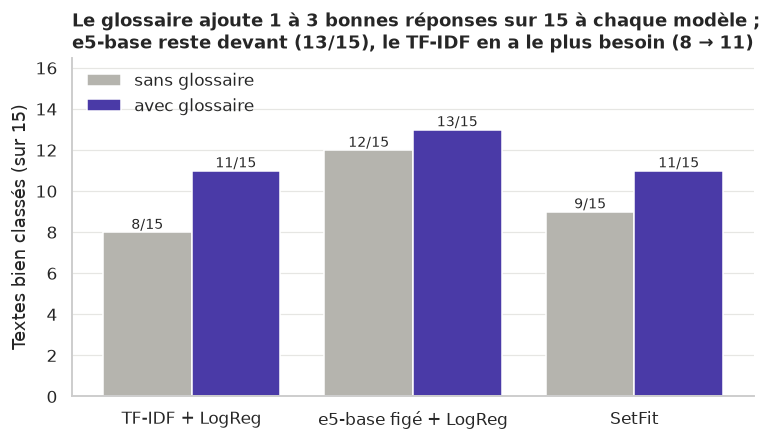

In [40]:
mixed_models = list(dict.fromkeys(model for model, _ in mixed_pred))
fig, ax = plt.subplots(figsize=(8, 4))
for offset, (variant, color) in zip([-0.2, 0.2], [("sans", "#b5b4ae"), ("avec", FAMILY_COLORS["dense figée"])]):
    n_correct = [int((mixed_pred[(model, variant)] == mixed["categorie"].to_numpy()).sum()) for model in mixed_models]
    bars = ax.bar(np.arange(len(mixed_models)) + offset, n_correct, width=0.4, color=color,
                  label=f"{variant} glossaire")
    ax.bar_label(bars, [f"{n}/15" for n in n_correct], fontsize=9)
ax.set_xticks(range(len(mixed_models)), mixed_models)
ax.set(ylabel="Textes bien classés (sur 15)", ylim=(0, 16.5))
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Le glossaire ajoute 1 à 3 bonnes réponses sur 15 à chaque modèle ;\n"
             "e5-base reste devant (13/15), le TF-IDF en a le plus besoin (8 → 11)", loc="left")
fig.savefig(FIGURES_DIR / "test_mixte_ewe.png")
plt.show()

In [41]:
with pd.option_context("display.max_colwidth", 70):
    display(mixed[["texte", "categorie", "groupe"]].assign(
        **{f"{model.split()[0]} {variant}": np.where(pred == mixed["categorie"].to_numpy(), "·", pred)
           for (model, variant), pred in mixed_pred.items()}))

,texte,categorie,groupe,TF-IDF sans,TF-IDF avec,e5-base sans,e5-base avec,SetFit sans,SetFit avec
0,"Accueil à la mairie de Bè, enyo ŋutɔ. Akpe kakaka aux agents.",Satisfaction,glossaire,Suggestion,·,·,·,Insatisfaction,·
1,"Aucun problème pour mon passeport, tout est allé kaba. Ayekoo !",Satisfaction,glossaire,·,·,·,·,·,·
2,"Guichet unique du foncier : é vivi ŋutɔ, pas de lala du tout.",Satisfaction,glossaire,Suggestion,·,·,·,Insatisfaction,Insatisfaction
3,"Le dispensaire de Tokoin m'a bien reçu, Mawu neyra mi.",Satisfaction,hors_glossaire,·,·,·,·,·,·
4,"Carte d'identité reçue en une semaine, medzɔ dzi ŋutɔ.",Satisfaction,hors_glossaire,Insatisfaction,·,·,·,Insatisfaction,Insatisfaction
5,"Je suis allé à la mairie pour un extrait de naissance. Lala geɖe, ...",Insatisfaction,glossaire,Satisfaction,Satisfaction,·,·,·,·
6,"Trois jours sans courant à Agoè, la CEET le megbe ŋutɔ, dziku geɖe.",Insatisfaction,glossaire,·,·,·,·,·,·
7,"Mele kɔdzi la ŋkeke etɔ̃, dɔwɔlawo mekpɔ dɔnɔwo o. Urgences de Syl...",Insatisfaction,hors_glossaire,·,·,·,·,Suggestion,·
8,"Au commissariat, bubu mele wo si o.",Insatisfaction,hors_glossaire,·,·,·,·,·,·
9,"Ils demandent ga pour chaque agbalẽ au tribunal, esia nye ŋukpe.",Insatisfaction,hors_glossaire,·,·,·,·,·,·


**Lecture** (« · » = prédiction juste). Avec 15 textes, **une erreur vaut 6,7 points** d'accuracy :
les écarts sont des tendances, pas des résultats établis.

- **Le glossaire aide les trois modèles, et d'abord le TF-IDF** : 8 → 11 textes justes (accuracy
  0,53 → 0,73), SetFit 9 → 11, e5-base 12 → 13. Sans glossaire, un mot éwé est un n-gramme jamais
  vu en entraînement : le sac de mots n'a plus que le français pour décider. e5 s'en sort mieux
  car la partie française (« trois jours sans courant », « mettez des bancs ») suffit souvent.
- **Le gain ne se limite pas aux textes `glossaire`** (4 → 5 sur 8 `hors_glossaire` pour le TF-IDF et
  SetFit) : ces textes contiennent souvent aussi un mot connu (`ga`, `agbalẽ`, `nublanui`), mais ce n'est pas le mot qui porte la polarité ;
  ils restent les moins bien classés.
- **Exemple où le glossaire corrige** : « Accueil à la mairie de Bè, enyo ŋutɔ. Akpe kakaka aux
  agents. » Sans glossaire, le TF-IDF y voit une Suggestion et SetFit une Insatisfaction ; avec
  « bon, très, merci, beaucoup », les deux passent à Satisfaction.
- **Exemple où il corrige e5** : « Il faudrait plus de dɔwɔla au guichet pour réduire la lala. »
  e5 sans glossaire lit une Insatisfaction (l'attente au guichet) ; avec « agent, attente », la forme
  « il faudrait plus de … pour … » l'emporte et le texte devient une Suggestion.
- **Exemple où le glossaire induit en erreur** : « Ne wotsɔ SMS yɔ mí hafi míava mairie la, anyo. »
  (« si on nous prévenait par SMS avant de venir, ce serait bien », Suggestion). `hafi` est glosé
  « vraiment » au lieu de « avant » et le conditionnel éwé (`ne … anyo`) n'est pas reconnu : e5 passe
  de Satisfaction (déjà faux) à Insatisfaction, et aucun modèle ne trouve la Suggestion.
  De même `mele` est glosé « ne pas » dans « Mele kɔdzi la… » où il signifie « je suis » ; la
  prédiction (Insatisfaction) est juste, mais par chance : la glose ajoute une négation qui n'existe pas.
  Le pluriel `dɔwɔlawo` (agents) n'est jamais reconnu, faute de lemmatisation du suffixe `-wo`.

Le glossaire est donc utile dès qu'un mot de polarité est couvert, et dangereux quand un mot
polysémique y a une seule glose : c'est la piste 4 de la section 3 (gloses selon le contexte, `-wo`).

### 4.2 Fine-tuning complet de CamemBERT

`almanach/camembert-base` (110 M paramètres) est affiné de bout en bout sur les 120 textes bruts du
train, avec une tête de classification neuve : 15 époques, lr 3·10⁻⁵ avec 10 % de warmup puis décroissance
linéaire, batch 16, `max_length` 64 (les textes font moins de 40 tokens), fp16. Trois graines pour mesurer
l'instabilité attendue d'un tel affinage sur si peu de données, puis une validation croisée sur les
**5 premiers plis de `cv_train`** (les mêmes que SetFit et que les 5 premiers plis d'e5-base : comparaison appariée).
~13 s par entraînement sur une RTX 2070 ; les poids ne sont pas sauvegardés, seuls les scores sont mis en
cache dans `models/camembert_scores.json` (`RUN_CAMEMBERT = True` pour refaire, GPU requis).

In [42]:
RUN_CAMEMBERT = False
CAMEMBERT_CHECKPOINT = "almanach/camembert-base"
CAMEMBERT_CACHE = MODELS_DIR / "camembert_scores.json"
CAMEMBERT_SEEDS = [42, 43, 44]


def finetune_camembert(seed, train_texts, train_labels, evaluation_texts, epochs=15, lr=3e-5, batch_size=16, max_length=64):
    """Affine CamemBERT et renvoie les classes prédites (fp16, warmup 10 %) ; les poids ne sont pas sauvegardés."""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(CAMEMBERT_CHECKPOINT)
    model = AutoModelForSequenceClassification.from_pretrained(CAMEMBERT_CHECKPOINT, num_labels=len(CLASS_ORDER)).cuda()

    def encode(batch_texts):
        return tokenizer(list(batch_texts), padding=True, truncation=True, max_length=max_length,
                         return_tensors="pt").to("cuda")

    label_ids = torch.tensor([CLASS_ORDER.index(label) for label in train_labels], device="cuda")
    n_steps = epochs * -(-len(train_texts) // batch_size)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * n_steps), n_steps)
    scaler = torch.amp.GradScaler()
    generator = torch.Generator().manual_seed(seed)
    model.train()
    for _ in range(epochs):
        for rows in torch.randperm(len(train_texts), generator=generator).split(batch_size):
            with torch.autocast("cuda", dtype=torch.float16):
                loss = model(**encode(train_texts.iloc[rows.numpy()]), labels=label_ids[rows.cuda()]).loss
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
    model.eval()
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        predictions = np.array(CLASS_ORDER)[model(**encode(evaluation_texts)).logits.argmax(dim=1).cpu().numpy()]
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return predictions


def camembert_test_run(seed):
    predictions = finetune_camembert(seed, X_train, y_train, X_test)
    return {"seed": seed, "accuracy": accuracy_score(y_test, predictions), "f1_macro": f1_macro(y_test, predictions),
            "erreurs": [f"{text} ({true} → {pred})" for text, true, pred in zip(X_test, y_test, predictions) if true != pred]}


if RUN_CAMEMBERT:
    start = time.perf_counter()
    camembert_runs = [camembert_test_run(seed) for seed in CAMEMBERT_SEEDS]
    camembert_cv_f1 = [f1_macro(y_train.iloc[validation_part],
                                finetune_camembert(SEED, X_train.iloc[train_part], y_train.iloc[train_part], X_train.iloc[validation_part]))
                       for train_part, validation_part in islice(cv_train.split(X_train, y_train), 5)]
    CAMEMBERT_CACHE.write_text(json.dumps({"runs": camembert_runs, "cv_f1": camembert_cv_f1,
                                           "seconds": time.perf_counter() - start}, indent=1))
camembert_results = json.loads(CAMEMBERT_CACHE.read_text())
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(camembert_results["runs"]).set_index("seed"))

,accuracy,f1_macro,erreurs
seed,,,
42,0.966667,0.966583,[Yèvu service la nyuie hafi! (Satisfaction → Insatisfaction)]
43,0.966667,0.966583,[Yèvu service la nyuie hafi! (Satisfaction → Insatisfaction)]
44,0.966667,0.966583,[Yèvu service la nyuie hafi! (Satisfaction → Insatisfaction)]


In [43]:
camembert_runs = pd.DataFrame(camembert_results["runs"])
print("Erreurs d'e5-base sur le test :", list(X_test[test_pred[RETAINED_MODEL] != y_test.to_numpy()]))
pd.DataFrame({
    **{name: {"F1 macro CV (5 mêmes plis)": f"{cv_scores[name].iloc[:5].mean():.3f} ± {cv_scores[name].iloc[:5].std():.3f}",
              "accuracy test": f"{accuracy_score(y_test, test_pred[name]):.3f}",
              "F1 macro test": f"{test_f1[name]:.3f}"} for name in [RETAINED_MODEL, "SetFit"]},
    "CamemBERT affiné (3 graines)": {
        "F1 macro CV (5 mêmes plis)": f"{np.mean(camembert_results['cv_f1']):.3f} ± {np.std(camembert_results['cv_f1'], ddof=1):.3f}",
        **{f"{label} test": f"{camembert_runs[column].mean():.3f} ± {camembert_runs[column].std():.3f}"
           for label, column in [("accuracy", "accuracy"), ("F1 macro", "f1_macro")]}},
}).T

Erreurs d'e5-base sur le test : ["Je n'ai reçu aucun accusé de réception de ma demande."]


,F1 macro CV (5 mêmes plis),accuracy test,F1 macro test
e5-base figé + LogReg,0.983 ± 0.023,0.967,0.967
SetFit,0.975 ± 0.023,1.000,1.000
CamemBERT affiné (3 graines),0.983 ± 0.037,0.967 ± 0.000,0.967 ± 0.000


**Lecture.** L'instabilité attendue **n'apparaît pas** : les trois graines donnent exactement le même
résultat, 0,967 d'accuracy et de F1 macro sur le test (σ = 0), soit 1 erreur sur 30, comme e5-base figé.
Mais pas sur le même texte : e5-base manque l'id 50 (« Je n'ai reçu aucun accusé… », la négation noyée
de 2.4), CamemBERT l'id 73 « Yèvu service la nyuie hafi! » (Satisfaction lue comme Insatisfaction).
Entièrement en éwé, ce texte est hors du vocabulaire d'un modèle pré-entraîné sur du français seul
(CamemBERT) : c'est la limite que la section 4.1 montre à plus grande échelle. Conclusion honnête : **sur ce test,
CamemBERT affiné égale e5-base figé sans le battre**, pour un coût bien plus élevé (GPU, 110 M paramètres
mis à jour, 440 Mo de poids par modèle entraîné contre quelques Ko pour la tête logistique). Le test de
30 textes ne peut pas les départager : d'où la validation croisée sur les 5 mêmes plis que les autres modèles.

**Validation croisée (5 plis appariés).** CamemBERT obtient **0,983 ± 0,037**, e5-base figé **0,983 ± 0,023**,
SetFit 0,975 ± 0,023 : égalité. CamemBERT fait 4 plis parfaits et chute à 0,917 sur le cinquième, d'où un écart-type
plus large : c'est l'instabilité attendue d'un affinage complet sur 96 textes, invisible sur le test. À score
égal, l'encodeur figé l'emporte par son coût (aucun GPU, une tête de quelques Ko).

### 4.3 Conclusion du bonus

- **Ce qui marche** : le glossaire additif, même sommaire, améliore les trois modèles sur les textes mixtes
  (TF-IDF 8 → 11 sur 15, e5-base 12 → 13) ; CamemBERT affiné atteint le niveau d'e5-base (0,983 en CV sur 5 plis appariés).
- **Ce qui ne marche pas** : affiner un encodeur (SetFit, CamemBERT) ne bat pas e5-base figé à 120 textes,
  et les textes majoritairement éwé ou à mot polysémique (`hafi`, `mele`) restent mal classés ; CamemBERT est
  plus variable d'un pli à l'autre (σ = 0,037 contre 0,023).
- **Suite** : pistes 3 et 4 de la section 3, un encodeur couvrant l'éwé et un glossaire contextuel validé
  par un locuteur, évalués sur un jeu mixte plus grand que 15 textes (piste 1).